# 04 — Segmentation: RFM, behavioural clusters, and the cells where they disagree

Three layers, and the third is the reason the notebook exists.

1. **RFM** — the interpretable baseline. Built knowing in advance that it is partly
   broken here: 77.5% of purchasers have exactly one order, so Frequency cannot be cut
   into terciles at all. That is reported, not worked around.
2. **Behavioural clustering** — k-means on eight standardised engagement / funnel /
   price / assortment features, named in business language, validated for statistical
   separation and for stability across time.
3. **The cross-tab** — RFM value against behavioural cluster, with the *disagreement*
   cells sized and characterised. Agreement cells tell you nothing you did not already
   know. The disagreements are where a targeting decision actually gets made, and they
   are what 08 inherits.

Inherited from `outputs/handoff_params.json`, not re-derived: the bot exclusion
(>29 sessions per active day, 1,605 users), the certified order-reconstruction rule,
the certified churn threshold (42.2d, region [30, 45]), and the bulk-buyer segment
(143 users, `is_bulk_buyer`).

---

### Binding constraint carried forward from 03 — stated here, not left to 08

**Churn at this retailer is first-purchase churn.** 87.8% of the users the certified
rule flags had exactly one order, against 80.0% of the validation panel. The at-risk
cells below are therefore **activation** problems — get a second order — and not
win-back problems. Every segment in this notebook is framed that way.

**The flagged population is not the at-risk population.** The certified rule flags
36,495 users; the true at-risk base is 61,787. Recall is 53.09%. The 28,986 missed
churners all sit *below* the 42.2d threshold (median recency 23.7d), so they are
invisible to any recency cut — and, as Section 4 shows, they sit in the cells that look
healthy. Any segment-level reach figure that does not divide through by recall is wrong
by roughly a factor of two.

In [1]:
import os, sys, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from scipy import stats
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, cohen_kappa_score

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

from src.plotting import frame, add_title, add_takeaway, save, show_df, thousands
from src.data import connect, materialize, create_orders_view, round_sig

SEED = 42
np.random.seed(SEED)
TABLES_DIR = os.path.join("outputs", "tables")
FIG_DIR = os.path.join("outputs", "figures")
PROCESSED_DIR = os.path.join("data", "processed")
for d in (TABLES_DIR, FIG_DIR, PROCESSED_DIR):
    os.makedirs(d, exist_ok=True)

with open(os.path.join("outputs", "handoff_params.json")) as f:
    handoff = json.load(f)

BOT        = handoff["bot_exclusion"]
BULK       = handoff["bulk_buyer_segment"]
CHURN      = handoff["churn_definition"]
K_CERT     = float(CHURN["certified_threshold_days"])
CERT_REGION= CHURN["certified_region_days"]
RECALL     = float(CHURN["validation"]["specB"]["recall_pct"]) / 100.0
ADDR       = CHURN["addressable_population"]
DATA_START = pd.Timestamp(handoff["data_date_range"]["min"])
DATA_END_HANDOFF = pd.Timestamp(handoff["data_date_range"]["max"])

def days(x):
    return pd.to_timedelta(round(float(x) * 86400.0, 6), unit="s")

print("INHERITED FROM handoff_params.json -- NOT RE-DERIVED")
print("=" * 78)
print(f"  bot exclusion     : {BOT['metric']} > {BOT['threshold']}  ->  {BOT['n_users_excluded']:,} users")
print(f"  order rule        : {handoff['order_reconstruction_rule']['rule']}")
print(f"  churn threshold   : {K_CERT}d  (certified region {CERT_REGION[0]:.0f}-{CERT_REGION[1]:.0f}d, NOT identified)")
print(f"  churn rule recall : {RECALL*100:.2f}%  -> flagged {ADDR['n_flagged']:,} vs true at-risk {ADDR['n_true_at_risk']:,}")
print(f"  bulk buyers       : {BULK['n_users']} users, {BULK['share_of_revenue_pct']}% of revenue -- {BULK['treatment'][:46]}...")
print(f"  data window       : {DATA_START} .. {DATA_END_HANDOFF}")

con = connect()
print("\nDuckDB ready (threads=6; determinism guardrails in src/data.py connect()).")

INHERITED FROM handoff_params.json -- NOT RE-DERIVED
  bot exclusion     : sessions per active day (distinct user_session count / distinct active-day count) > 29.0  ->  1,605 users
  order rule        : GROUP BY (user_id, user_session, event_time) on event_type='purchase' rows
  churn threshold   : 42.2d  (certified region 30-45d, NOT identified)
  churn rule recall : 53.09%  -> flagged 36,495 vs true at-risk 61,787
  bulk buyers       : 143 users, 1.445% of revenue -- KEEP and flag as a named segment (is_bulk_buye...
  data window       : 2019-10-01 00:00:00 .. 2020-02-29 23:59:59

DuckDB ready (threads=6; determinism guardrails in src/data.py connect()).


In [2]:
t0 = time.time()
con.execute("CREATE OR REPLACE VIEW ev_raw AS SELECT * FROM read_csv_auto('data/raw/*.csv', filename=true)")
con.execute("CREATE OR REPLACE VIEW ev0 AS SELECT * FROM ev_raw WHERE user_session IS NOT NULL")

# Bot list re-APPLIED from the certified threshold, not re-derived.
con.execute(f'''
CREATE OR REPLACE VIEW bot_users AS
WITH u AS (SELECT user_id, count(DISTINCT user_session) n_sessions,
           count(DISTINCT date_trunc('day', event_time)) n_active_days FROM ev0 GROUP BY user_id)
SELECT user_id FROM u WHERE n_sessions*1.0/n_active_days > {float(BOT['threshold'])}
''')
n_bot = con.execute("SELECT count(*) FROM bot_users").fetchone()[0]
assert n_bot == BOT["n_users_excluded"], f"bot list drifted: {n_bot} vs {BOT['n_users_excluded']}"

materialize(con, "ev", "SELECT * FROM ev0 WHERE user_id NOT IN (SELECT user_id FROM bot_users)")
create_orders_view(con, events_view="ev", view_name="orders_v")
materialize(con, "orders", "SELECT * FROM orders_v")
materialize(con, "first_order", '''
    SELECT user_id, user_session AS first_session, order_ts AS first_ts
    FROM (SELECT *, row_number() OVER (PARTITION BY user_id ORDER BY order_ts, user_session) rn
          FROM orders) WHERE rn = 1''')

DATA_END = con.execute("SELECT max(event_time) FROM ev").fetchone()[0]
n_orders = con.execute("SELECT count(*) FROM orders").fetchone()[0]
n_purchasers = con.execute("SELECT count(DISTINCT user_id) FROM orders").fetchone()[0]
print(f"ev rebuilt | orders={n_orders:,} | purchasers={n_purchasers:,} | DATA_END={DATA_END}  [{time.time()-t0:.0f}s]")

# Reconcile the rebuild against what 02/03 committed to disk, rather than trusting it.
orders_pd = con.execute("SELECT user_id, user_session, order_ts, n_items, order_value FROM orders").fetchdf()
orders_disk = pd.read_parquet(os.path.join(PROCESSED_DIR, "orders.parquet"))
assert len(orders_pd) == len(orders_disk) == 158399, (len(orders_pd), len(orders_disk))
key = lambda d: set(zip(d.user_id, d.user_session.astype(str), d.order_ts.astype("datetime64[us]")))
assert key(orders_pd) == key(orders_disk), "rebuilt orders disagree with the persisted orders.parquet"
print(f"Rebuilt `orders` reconciles row-for-row with data/processed/orders.parquet ({len(orders_pd):,} orders).")

churn_flags = pd.read_parquet(os.path.join(PROCESSED_DIR, "churn_flags.parquet"))
cohorts     = pd.read_parquet(os.path.join(PROCESSED_DIR, "cohort_assignments.parquet"))
assert len(churn_flags) == len(cohorts) == n_purchasers, (len(churn_flags), len(cohorts), n_purchasers)
assert int(churn_flags.is_bulk_buyer.sum()) == BULK["n_users"]
print(f"03's churn_flags and 02's cohort_assignments loaded: {n_purchasers:,} purchasers each (match).")

ev rebuilt | orders=158,399 | purchasers=109,732 | DATA_END=2020-02-29 23:59:59  [20s]


Rebuilt `orders` reconciles row-for-row with data/processed/orders.parquet (158,399 orders).
03's churn_flags and 02's cohort_assignments loaded: 109,732 purchasers each (match).


## 0. The population this notebook segments, and what it leaves out

Every layer runs on **bot-excluded purchasers** — the 109,732 users with at least one
reconstructed order. That is a deliberate narrowing and it has a cost worth stating
once: the other ~1.53M users who browsed and never bought are not segmented here. They
are a different problem (acquisition/first conversion), 01 covers their funnel, and
including them would make Frequency and Monetary undefined for 93% of the rows.

The consequence for 08: this notebook can say who among *buyers* to target for a second
order. It cannot say anything about non-buyers.

In [3]:
print("POPULATION")
print("=" * 78)
n_any = handoff["row_counts"]["n_users_any_event"]
print(f"  users with any event (00, pre-bot-exclusion) : {n_any:,}")
print(f"  bot-excluded users                           : {BOT['n_users_excluded']:,}")
print(f"  PURCHASERS (this notebook's population)      : {n_purchasers:,}  "
      f"({100*n_purchasers/n_any:.2f}% of the event base)")
print(f"  of whom bulk buyers (kept, flagged)          : {BULK['n_users']:,}")
print()
print("ONE-ORDER SHARE -- two different denominators, both quoted in this project:")
share_all = (churn_flags.n_orders_total == 1).mean() * 100
panel = churn_flags[churn_flags.in_validation_panel]
share_panel = (panel.n_orders_at_flag == 1).mean() * 100
share_flagged = (panel.loc[panel.flagged_churned, "n_orders_at_flag"] == 1).mean() * 100
print(f"  all purchasers at DATA_END      : {share_all:.2f}%  (n={len(churn_flags):,})   <- this notebook")
print(f"  03's validation panel at F*     : {share_panel:.2f}%  (n={len(panel):,})    <- the '80.0%' in handoff")
print(f"  03's FLAGGED users at F*        : {share_flagged:.2f}%  (n={int(panel.flagged_churned.sum()):,})")
print()
print("  The 77.5 / 80.0 difference is the anchor, not a discrepancy: the panel counts orders")
print("  as at F* (2020-01-04) and excludes users whose first order came after it. Both are")
print("  correct for their own question. Quoted together they must carry their denominators.")

POPULATION
  users with any event (00, pre-bot-exclusion) : 1,639,358
  bot-excluded users                           : 1,605
  PURCHASERS (this notebook's population)      : 109,732  (6.69% of the event base)
  of whom bulk buyers (kept, flagged)          : 143

ONE-ORDER SHARE -- two different denominators, both quoted in this project:
  all purchasers at DATA_END      : 77.46%  (n=109,732)   <- this notebook
  03's validation panel at F*     : 79.97%  (n=72,827)    <- the '80.0%' in handoff
  03's FLAGGED users at F*        : 87.78%  (n=36,495)

  The 77.5 / 80.0 difference is the anchor, not a discrepancy: the panel counts orders
  as at F* (2020-01-04) and excludes users whose first order came after it. Both are
  correct for their own question. Quoted together they must carry their denominators.


## 1. LAYER 1 — RFM, the interpretable baseline

### 1A. The snapshot date, and why it has to be this one

RFM is a **stock** measure: it describes every user as of one moment. That moment is
fixed at `DATA_END = 2020-02-29 23:59:59`, the last event in the bot-excluded data, for
one reason that is not cosmetic — 03 persisted `churned_at_data_end` measured at exactly
this instant. Choosing any other snapshot would make the RFM recency score and the churn
flag refer to different moments, and Section 4 cross-tabs the two. They have to share a
clock.

The cost of that choice, stated plainly:

- **Recency is left-censored at 151 days.** No user can have a recency above the length
  of the observation window, so the RFM "worst recency" tercile is a floor, not a true
  long-lapsed population. A mature retailer would have customers two years dormant; this
  data cannot contain one.
- **`churned_at_data_end` is unvalidated by construction.** There is no data after
  `DATA_END` to score it against. It is used here as a descriptive attribute of a
  segment, never as a validated outcome.

In [4]:
SNAP = DATA_END_HANDOFF
assert pd.Timestamp(DATA_END) <= SNAP
SPAN_DAYS = (SNAP - DATA_START).total_seconds() / 86400.0

rfm = orders_pd.groupby("user_id").agg(
    F=("order_ts", "size"),
    M=("order_value", "sum"),
    med_basket=("order_value", "median"),
    last_order_ts=("order_ts", "max"),
    first_order_ts=("order_ts", "min"),
).reset_index()
rfm["R"] = (SNAP - rfm.last_order_ts).dt.total_seconds() / 86400.0
rfm["tenure_d"] = (SNAP - rfm.first_order_ts).dt.total_seconds() / 86400.0
rfm = rfm.merge(
    churn_flags[["user_id", "is_bulk_buyer", "churned_at_data_end", "recency_at_data_end_days", "is_bf_cohort"]],
    on="user_id", how="inner")
assert len(rfm) == n_purchasers

# Recency must reproduce 03's exactly -- it is the same quantity at the same instant.
max_dev = float(np.abs(rfm.R - rfm.recency_at_data_end_days).max())
assert max_dev < 1e-6, max_dev
print(f"Snapshot date        : {SNAP}")
print(f"Observation span     : {SPAN_DAYS:.2f} days  -> recency is censored at this value")
print(f"Recency reproduces 03's recency_at_data_end_days exactly (max deviation {max_dev:.2e} days).")
print(f"Max observed recency : {rfm.R.max():.2f}d   |  churn threshold {K_CERT}d")
print(f"Share already past the certified churn threshold at the snapshot: "
      f"{100*(rfm.R >= K_CERT).mean():.2f}%  (= 03's churned_at_data_end, {100*rfm.churned_at_data_end.mean():.2f}%)")

Snapshot date        : 2020-02-29 23:59:59
Observation span     : 152.00 days  -> recency is censored at this value
Recency reproduces 03's recency_at_data_end_days exactly (max deviation 0.00e+00 days).
Max observed recency : 151.99d   |  churn threshold 42.2d
Share already past the certified churn threshold at the snapshot: 65.96%  (= 03's churned_at_data_end, 65.96%)


### 1B. Frequency is near-degenerate, and that breaks the F axis before it is built

This is reported *before* the grid, because it determines what the grid can mean.

In [5]:
fdist = rfm.F.value_counts().sort_index().to_frame("n_users")
fdist["pct"] = 100 * fdist.n_users / len(rfm)
fdist["cum_pct"] = fdist.pct.cumsum()
fdist = fdist.reset_index().rename(columns={"index": "n_orders", "F": "n_orders"})
show_df(fdist.head(10).round(3), name="nb04_frequency_distribution", max_rows=10)

q33, q67 = rfm.F.quantile(1/3), rfm.F.quantile(2/3)
print()
print("WHAT THIS DOES TO A TERCILE CUT ON FREQUENCY")
print("=" * 78)
print(f"  share with exactly 1 order : {100*(rfm.F==1).mean():.2f}%")
print(f"  F at the 33.3rd percentile : {q33:.0f}")
print(f"  F at the 66.7th percentile : {q67:.0f}")
print()
print("  Both tercile boundaries fall on F = 1. A quantile cut on Frequency is IMPOSSIBLE:")
print("  any three-way split puts ~77% of the base in one bucket and cannot separate the")
print("  other two. Frequency carries almost no information at this retailer because")
print("  almost nobody has bought twice.")
print()
print("  DECISION: F is scored on NATURAL BREAKS (1 / 2 / 3+ orders), not on terciles.")
print("  This is not a tercile and is not labelled as one. Resulting shares:")
for lbl, msk in [("F_score=1  (1 order) ", rfm.F == 1),
                 ("F_score=2  (2 orders)", rfm.F == 2),
                 ("F_score=3  (3+ orders)", rfm.F >= 3)]:
    print(f"    {lbl}: {int(msk.sum()):>7,}  ({100*msk.mean():5.2f}%)")
print()
print("  CONSEQUENCE FOR THE RFM CELLS: the composite RFM score is driven overwhelmingly")
print("  by R and M. F changes the score for only the ~22.5% of users with a repeat order.")
print("  Any claim that RFM 'segments by loyalty' here would be false -- there is almost")
print("  no loyalty in the data to segment on. This is the same structural fact that")
print("  makes 08 an ACTIVATION problem.")

   n_orders  n_users     pct  cum_pct
0         1    85001  77.462   77.462
1         2    14736  13.429   90.891
2         3     4931   4.494   95.385
3         4     2241   2.042   97.427
4         5     1133   1.033   98.460
5         6      644   0.587   99.047
6         7      343   0.313   99.359
7         8      233   0.212   99.572
8         9      158   0.144   99.716
9        10       79   0.072   99.788



WHAT THIS DOES TO A TERCILE CUT ON FREQUENCY
  share with exactly 1 order : 77.46%
  F at the 33.3rd percentile : 1
  F at the 66.7th percentile : 1

  Both tercile boundaries fall on F = 1. A quantile cut on Frequency is IMPOSSIBLE:
  any three-way split puts ~77% of the base in one bucket and cannot separate the
  other two. Frequency carries almost no information at this retailer because
  almost nobody has bought twice.

  DECISION: F is scored on NATURAL BREAKS (1 / 2 / 3+ orders), not on terciles.
  This is not a tercile and is not labelled as one. Resulting shares:
    F_score=1  (1 order) :  85,001  (77.46%)
    F_score=2  (2 orders):  14,736  (13.43%)
    F_score=3  (3+ orders):   9,995  ( 9.11%)

  CONSEQUENCE FOR THE RFM CELLS: the composite RFM score is driven overwhelmingly
  by R and M. F changes the score for only the ~22.5% of users with a repeat order.
  Any claim that RFM 'segments by loyalty' here would be false -- there is almost
  no loyalty in the data to segment

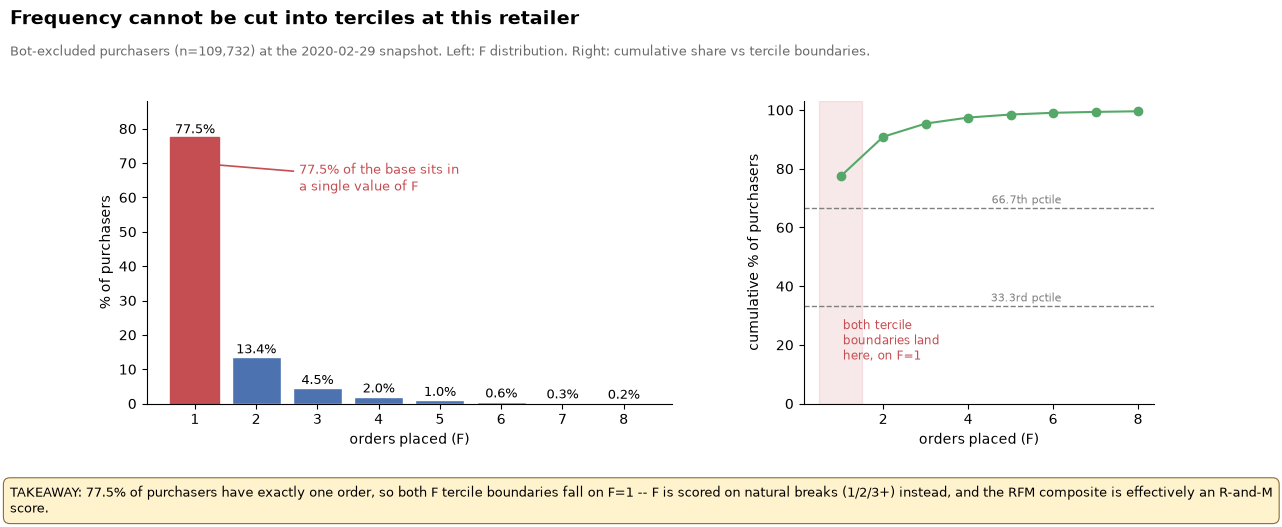

In [6]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 5.4), gridspec_kw={"width_ratios": [3, 2]})
fig.subplots_adjust(top=0.80, bottom=0.24, wspace=0.30)

top = fdist.head(8)
bars = ax.bar(top.n_orders.astype(str), top.pct, color="#4C72B0", edgecolor="white")
bars[0].set_color("#C44E52")
for b, v in zip(bars, top.pct):
    ax.text(b.get_x() + b.get_width()/2, v + 1.2, f"{v:.1f}%", ha="center", fontsize=9)
ax.set_xlabel("orders placed (F)"); ax.set_ylabel("% of purchasers")
ax.set_ylim(0, 88); ax.spines[["top", "right"]].set_visible(False)
ax.annotate("77.5% of the base sits in\na single value of F", xy=(0, 70), xytext=(1.7, 62),
            fontsize=9.5, color="#C44E52",
            arrowprops=dict(arrowstyle="->", color="#C44E52", lw=1.2))

ax2.plot(top.n_orders, top.cum_pct, marker="o", color="#55A868")
ax2.axhline(33.3, ls="--", lw=1, color="gray"); ax2.axhline(66.7, ls="--", lw=1, color="gray")
ax2.text(6.2, 34.8, "33.3rd pctile", fontsize=8, color="gray", ha="right")
ax2.text(6.2, 68.2, "66.7th pctile", fontsize=8, color="gray", ha="right")
ax2.axvspan(0.5, 1.5, color="#C44E52", alpha=0.12)
ax2.text(1.05, 15, "both tercile\nboundaries land\nhere, on F=1", fontsize=8.5, color="#C44E52")
ax2.set_xlabel("orders placed (F)"); ax2.set_ylabel("cumulative % of purchasers")
ax2.set_ylim(0, 103); ax2.spines[["top", "right"]].set_visible(False)

add_title(fig, "Frequency cannot be cut into terciles at this retailer",
          "Bot-excluded purchasers (n=109,732) at the 2020-02-29 snapshot. Left: F distribution. Right: cumulative share vs tercile boundaries.")
add_takeaway(fig, "77.5% of purchasers have exactly one order, so both F tercile boundaries fall on F=1 -- "
                  "F is scored on natural breaks (1/2/3+) instead, and the RFM composite is effectively an R-and-M score.")
save(fig, "nb04_rfm_frequency_degeneracy"); plt.show()

### 1C. R and M, and the bulk-buyer treatment

R and M are genuinely continuous, so they take real tercile cuts. Two things are handled
explicitly here:

- **Bulk buyers** (143 reseller/B2B-like users, 1.45% of revenue). Per the handoff
  treatment they are **kept and flagged**, and excluded from every *mean*-based monetary
  figure. Every monetary headline in this notebook is a **median**, so the exclusion
  changes no headline — the mean is reported both ways below purely to show the size of
  what is being avoided.
- **The recency tercile boundary is almost exactly the churn threshold.** This is not
  designed, and it means the worst-recency tercile and the churn flag are near-duplicates.
  Section 4 depends on knowing that.

In [7]:
r33, r67 = rfm.R.quantile(1/3), rfm.R.quantile(2/3)
m33, m67 = rfm.M.quantile(1/3), rfm.M.quantile(2/3)
print("TERCILE BOUNDARIES (exact quantiles, all purchasers)")
print("=" * 78)
print(f"  R (days since last order): {r33:.2f}d , {r67:.2f}d")
print(f"  M (total order value EUR): {m33:.2f} , {m67:.2f}")
print()
print(f"  NOTE: the better R boundary ({r33:.2f}d) sits {abs(r33-K_CERT):.2f}d from the certified")
print(f"  churn threshold ({K_CERT}d). The freshest recency tercile is therefore almost exactly")
print(f"  the not-churned set: {100*(rfm.R < r33).mean():.2f}% vs {100*(~rfm.churned_at_data_end).mean():.2f}% not churned.")
print(f"  R and the churn flag are close to the same variable -- Section 4 relies on this.")
print()
print("BULK-BUYER TREATMENT (handoff: exclude from MEAN-based monetary metrics)")
print("=" * 78)
nb_ = ~rfm.is_bulk_buyer
mono = pd.DataFrame([
    {"metric": "M: total order value per user", "all_users_mean": rfm.M.mean(),
     "ex_bulk_mean": rfm.loc[nb_, "M"].mean(), "HEADLINE_median": rfm.M.median(),
     "ex_bulk_median": rfm.loc[nb_, "M"].median()},
    {"metric": "median basket value per user", "all_users_mean": rfm.med_basket.mean(),
     "ex_bulk_mean": rfm.loc[nb_, "med_basket"].mean(), "HEADLINE_median": rfm.med_basket.median(),
     "ex_bulk_median": rfm.loc[nb_, "med_basket"].median()},
]).round(2)
mono["mean_shift_from_bulk"] = (mono.all_users_mean - mono.ex_bulk_mean).round(2)
show_df(mono, name="nb04_bulk_buyer_monetary_treatment")
print(f"\n  143 bulk buyers move the MEAN of M by EUR {mono.mean_shift_from_bulk.iloc[0]:.2f} and the MEDIAN by EUR "
      f"{rfm.M.median()-rfm.loc[nb_,'M'].median():.2f}. Medians are the headline throughout, so no headline moves.")

TERCILE BOUNDARIES (exact quantiles, all purchasers)
  R (days since last order): 41.11d , 94.63d
  M (total order value EUR): 20.63 , 48.25

  NOTE: the better R boundary (41.11d) sits 1.09d from the certified
  churn threshold (42.2d). The freshest recency tercile is therefore almost exactly
  the not-churned set: 33.33% vs 34.04% not churned.
  R and the churn flag are close to the same variable -- Section 4 relies on this.

BULK-BUYER TREATMENT (handoff: exclude from MEAN-based monetary metrics)
                          metric  all_users_mean  ex_bulk_mean  HEADLINE_median  ex_bulk_median  mean_shift_from_bulk
0  M: total order value per user           57.35         56.59             33.1           33.02                  0.76
1   median basket value per user           37.43         37.01             26.9           26.84                  0.42

  143 bulk buyers move the MEAN of M by EUR 0.76 and the MEDIAN by EUR 0.08. Medians are the headline throughout, so no headline moves.


### 1D. The RFM grid

`RFM_sum = R_score + F_score + M_score`, each in {1,2,3}, so the composite runs 3–9.
Because F is a natural-break score rather than a tercile and the composite is a small
integer, the resulting "terciles" cannot be equal thirds. The achieved shares are
reported rather than forced.

In [8]:
rfm["R_score"] = pd.qcut(-rfm.R, 3, labels=[1, 2, 3]).astype(int)     # recent = 3
rfm["F_score"] = np.where(rfm.F == 1, 1, np.where(rfm.F == 2, 2, 3))  # natural breaks, NOT terciles
rfm["M_score"] = pd.qcut(rfm.M, 3, labels=[1, 2, 3]).astype(int)
rfm["RFM_sum"] = rfm.R_score + rfm.F_score + rfm.M_score
rfm["rfm_tercile"] = pd.cut(rfm.RFM_sum, [2, 4, 6, 9], labels=["Low", "Mid", "High"])

# A recency-free VALUE axis. Needed in Section 4: R is near-identical to the churn flag,
# so "high value AND at risk" cannot be expressed on a composite that already contains R.
rfm["value_score"] = rfm.F_score + rfm.M_score
rfm["value_tercile"] = pd.cut(rfm.value_score, [1, 2, 4, 6], labels=["Low", "Mid", "High"])

sumd = rfm.RFM_sum.value_counts().sort_index().to_frame("n_users")
sumd["pct"] = (100 * sumd.n_users / len(rfm)).round(2)
sumd.index.name = "RFM_sum"
show_df(sumd.reset_index(), name="nb04_rfm_composite_distribution", max_rows=10)

grid = rfm.groupby("rfm_tercile", observed=True).agg(
    n_users=("user_id", "size"), R_median_d=("R", "median"), F_median=("F", "median"),
    M_median_eur=("M", "median"), basket_median_eur=("med_basket", "median"),
    repeat_pct=("F", lambda s: 100*(s > 1).mean()),
    churn_flag_pct=("churned_at_data_end", lambda s: 100*s.mean()),
    tenure_median_d=("tenure_d", "median")).round(2)
grid["pct_of_base"] = (100 * grid.n_users / len(rfm)).round(2)
print("\nRFM TERCILE PROFILE  (denominator: all 109,732 bot-excluded purchasers at the snapshot)")
show_df(grid.reset_index(), name="nb04_rfm_tercile_profile")
print()
print(f"  Achieved shares Low/Mid/High = {grid.pct_of_base.tolist()} -- NOT equal thirds, and cannot be:")
print("  RFM_sum is an integer on 3..9 built from a degenerate F, so the cut points are lumpy.")
print()
print("  Read the churn column: Low=99.4% churn-flagged, High=26.6%. That is NOT a validation")
print("  of RFM. R_score is built from recency and the churn flag IS a recency cut at 42.2d --")
print("  the two are mechanically the same variable. It is reported so the circularity is")
print("  visible rather than mistaken for predictive power.")

   RFM_sum  n_users    pct
0        3    13226  12.05
1        4    24516  22.34
2        5    29245  26.65
3        6    18708  17.05
4        7    11291  10.29
5        8     6597   6.01
6        9     6149   5.60

RFM TERCILE PROFILE  (denominator: all 109,732 bot-excluded purchasers at the snapshot)
  rfm_tercile  n_users  R_median_d  F_median  M_median_eur  basket_median_eur  repeat_pct  churn_flag_pct  tenure_median_d  pct_of_base
0         Low    37742      107.17       1.0         15.89              15.87        0.44           99.36           107.23        34.39
1         Mid    47953       54.26       1.0         36.03              33.20       11.86           59.41            56.57        43.70
2        High    24037       27.30       2.0         91.53              45.52       78.53           26.58            87.31        21.91

  Achieved shares Low/Mid/High = [34.39, 43.7, 21.91] -- NOT equal thirds, and cannot be:
  RFM_sum is an integer on 3..9 built from a degenerate F, s

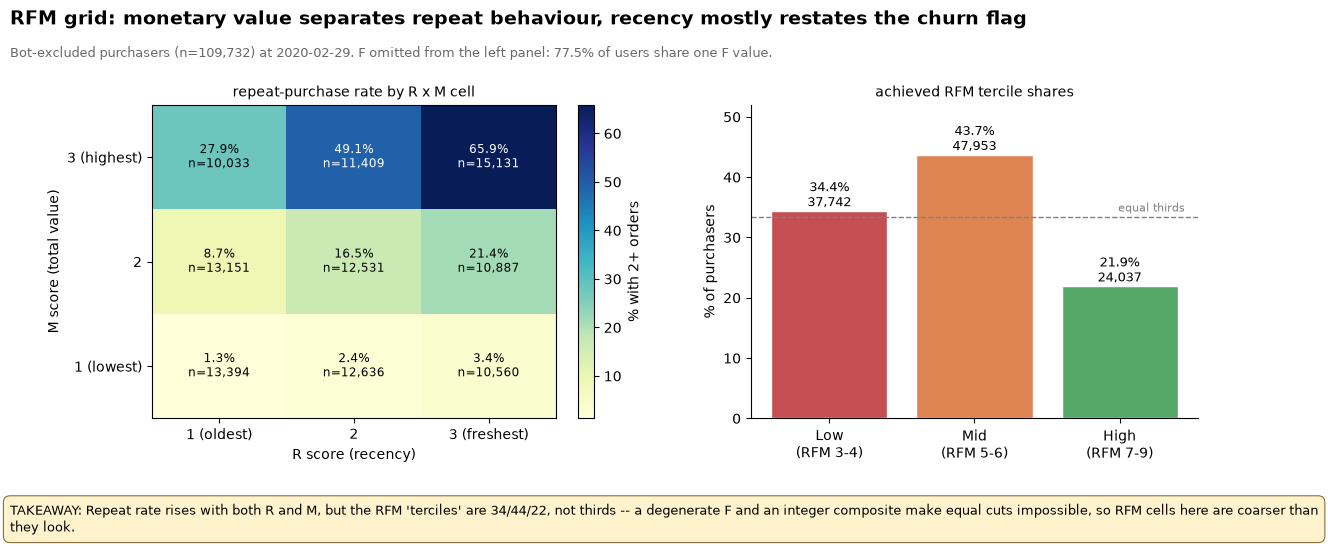

In [9]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.6))
fig.subplots_adjust(top=0.80, bottom=0.24, wspace=0.34)

cell_n = rfm.pivot_table(index="M_score", columns="R_score", values="user_id", aggfunc="size")
cell_rep = rfm.pivot_table(index="M_score", columns="R_score", values="F", aggfunc=lambda s: 100*(s > 1).mean())
im = ax.imshow(cell_rep.values, cmap="YlGnBu", aspect="auto", origin="lower")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cell_rep.values[i,j]:.1f}%\nn={cell_n.values[i,j]:,}", ha="center", va="center",
                fontsize=8.5, color="white" if cell_rep.values[i, j] > 28 else "black")
ax.set_xticks(range(3), ["1 (oldest)", "2", "3 (freshest)"]); ax.set_yticks(range(3), ["1 (lowest)", "2", "3 (highest)"])
ax.set_xlabel("R score (recency)"); ax.set_ylabel("M score (total value)")
ax.set_title("repeat-purchase rate by R x M cell", fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046, label="% with 2+ orders")

sh = grid.pct_of_base.values
b = ax2.bar(["Low\n(RFM 3-4)", "Mid\n(RFM 5-6)", "High\n(RFM 7-9)"], sh,
            color=["#C44E52", "#DD8452", "#55A868"], edgecolor="white")
for bb, v, nn in zip(b, sh, grid.n_users.values):
    ax2.text(bb.get_x()+bb.get_width()/2, v+0.8, f"{v:.1f}%\n{nn:,}", ha="center", fontsize=9)
ax2.axhline(33.33, ls="--", lw=1, color="gray")
ax2.text(2.45, 34.3, "equal thirds", fontsize=8, color="gray", ha="right")
ax2.set_ylabel("% of purchasers"); ax2.set_ylim(0, 52)
ax2.spines[["top", "right"]].set_visible(False)
ax2.set_title("achieved RFM tercile shares", fontsize=10)

add_title(fig, "RFM grid: monetary value separates repeat behaviour, recency mostly restates the churn flag",
          "Bot-excluded purchasers (n=109,732) at 2020-02-29. F omitted from the left panel: 77.5% of users share one F value.")
add_takeaway(fig, "Repeat rate rises with both R and M, but the RFM 'terciles' are 34/44/22, not thirds -- "
                  "a degenerate F and an integer composite make equal cuts impossible, so RFM cells here are coarser than they look.")
save(fig, "nb04_rfm_grid"); plt.show()

## 2. LAYER 2 — behavioural clustering

### 2A. Features, and the leakage constraint

Candidate set as briefed: sessions per active week, mean session depth, view-to-cart,
cart-to-purchase, cart abandonment rate, mean price percentile viewed, price range
viewed, brand entropy (NULL kept as its own level), category entropy, mean inter-session
gap.

**Leakage constraint (`leakage_rules_for_05`).** No feature may be derived from a
cart-abandonment *type* whose definition references the outcome window. The decision here
is simple: **no abandonment types are used at all.** Only abandonment *volume* and *rate*,
which 02 Section 0E established is the part that survives. `abandonment_user_types_leakage_safe.parquet`
is loaded and checked for coverage but deliberately not joined into the feature matrix.

**Classification window.** Features are computed over each user's **full observed
history up to the snapshot** (2019-10-01 → 2020-02-29). That is correct for a *descriptive*
segmentation — the segment is what the user looks like now, and 08's intervention happens
after the snapshot, so there is no outcome window to leak from. It is **not** automatically
safe as a predictor input in 05, and that is flagged in the persisted output: 05 must
recompute assignments on a pre-outcome window using the scaler and centroids persisted in
Section 6, not reuse these labels as features.

**Three departures from the candidate set, each measured before it is made** — 2B and 2C.

In [10]:
t1 = time.time()
materialize(con, "ue", '''
    SELECT e.user_id, e.user_session, e.event_time, e.event_type, e.product_id,
           e.category_id, e.brand, e.price, f.first_ts
    FROM ev e JOIN first_order f USING (user_id)''')
materialize(con, "prod_pct", '''
    WITH pm AS (SELECT product_id, quantile_cont(price, 0.5) med_price
                FROM ev WHERE price > 0 GROUP BY product_id)
    SELECT product_id, med_price,
           percent_rank() OVER (ORDER BY med_price, product_id) AS price_pct
    FROM pm''')
print(f"purchaser-event table + product price percentiles built [{time.time()-t1:.0f}s]")

# Funnel ratios use DISTINCT PRODUCTS, not event counts. 00 certified that the 10.4% exact
# duplicate rows (98% of them cart/remove_from_cart) must NOT be deduped -- they are real
# repeated telemetry. Counting events would therefore make view-to-cart a measure of
# logging intensity rather than of funnel behaviour; product-distinct bases are immune.
FEATURE_SQL = '''
WITH e AS (SELECT * FROM ue WHERE {W}),
sess AS (SELECT user_id, user_session, count(*) n_ev, min(event_time) s_start FROM e GROUP BY 1,2),
su AS (SELECT user_id, count(*) n_sessions, avg(n_ev) mean_session_depth FROM sess GROUP BY 1),
gp AS (SELECT user_id, avg(gap_d) mean_intersession_gap_d FROM (
         SELECT user_id, date_diff('second', lag(s_start) OVER (PARTITION BY user_id ORDER BY s_start, user_session),
                s_start)/86400.0 gap_d FROM sess) WHERE gap_d IS NOT NULL GROUP BY 1),
cn AS (SELECT user_id,
        count(*) FILTER (WHERE event_type='view') n_view_ev,
        count(*) FILTER (WHERE event_type='cart') n_cart_ev,
        count(*) FILTER (WHERE event_type='remove_from_cart') n_rem_ev,
        count(DISTINCT product_id) FILTER (WHERE event_type='view') p_view,
        count(DISTINCT product_id) FILTER (WHERE event_type='cart') p_cart,
        count(DISTINCT product_id) FILTER (WHERE event_type='purchase') p_purch,
        count(DISTINCT date_trunc('week', event_time)) n_active_weeks,
        count(DISTINCT date_trunc('day', event_time)) n_active_days
       FROM e GROUP BY 1),
ab AS (SELECT c.user_id, count(*) p_carted_not_bought FROM
        (SELECT DISTINCT user_id, product_id FROM e WHERE event_type='cart') c
        LEFT JOIN (SELECT DISTINCT user_id, product_id FROM e WHERE event_type='purchase') b
          ON c.user_id=b.user_id AND c.product_id=b.product_id
        WHERE b.product_id IS NULL GROUP BY 1),
pv AS (SELECT e.user_id, avg(p.price_pct) mean_price_pct_viewed,
              quantile_cont(p.price_pct,0.9)-quantile_cont(p.price_pct,0.1) price_range_viewed,
              count(*) n_priced_views
       FROM e JOIN prod_pct p USING (product_id) WHERE e.event_type='view' GROUP BY 1),
bd AS (SELECT user_id, coalesce(brand,'__NULL__') lvl, count(*) c FROM e WHERE event_type='view' GROUP BY 1,2),
be AS (SELECT user_id, -sum(pr*log2(pr)) brand_entropy,
              coalesce(sum(c) FILTER (WHERE lvl<>'__NULL__'),0)*1.0/sum(c) brand_coverage
       FROM (SELECT user_id,lvl,c,c*1.0/sum(c) OVER (PARTITION BY user_id) pr FROM bd) GROUP BY 1),
cd AS (SELECT user_id, category_id lvl, count(*) c FROM e
       WHERE event_type='view' AND category_id IS NOT NULL GROUP BY 1,2),
ce AS (SELECT user_id, -sum(pr*log2(pr)) category_entropy, count(*) n_cats
       FROM (SELECT user_id,lvl,c,c*1.0/sum(c) OVER (PARTITION BY user_id) pr FROM cd) GROUP BY 1)
SELECT su.user_id, su.n_sessions, su.mean_session_depth, gp.mean_intersession_gap_d,
       cn.n_view_ev, cn.n_cart_ev, cn.n_rem_ev, cn.p_view, cn.p_cart, cn.p_purch,
       cn.n_active_weeks, cn.n_active_days,
       su.n_sessions*1.0/cn.n_active_weeks AS sessions_per_active_week,
       cn.p_cart*1.0/nullif(cn.p_view,0) AS view_to_cart,
       cn.p_purch*1.0/nullif(cn.p_cart,0) AS cart_to_purchase,
       coalesce(ab.p_carted_not_bought,0)*1.0/nullif(cn.p_cart,0) AS cart_abandonment_rate,
       pv.mean_price_pct_viewed, pv.price_range_viewed, pv.n_priced_views,
       be.brand_entropy, be.brand_coverage, ce.category_entropy, ce.n_cats
FROM su JOIN cn USING (user_id) LEFT JOIN gp USING (user_id) LEFT JOIN ab USING (user_id)
     LEFT JOIN pv USING (user_id) LEFT JOIN be USING (user_id) LEFT JOIN ce USING (user_id)
'''

WINDOWS = {
    "full":   "TRUE",
    "octdec": "event_time <  TIMESTAMP '2020-01-01'",
    "novdec": "event_time >= TIMESTAMP '2019-11-01' AND event_time < TIMESTAMP '2020-01-01'",
    "janfeb": "event_time >= TIMESTAMP '2020-01-01'",
}
FLOAT_COLS = ["mean_session_depth", "mean_intersession_gap_d", "sessions_per_active_week",
              "view_to_cart", "cart_to_purchase", "cart_abandonment_rate",
              "mean_price_pct_viewed", "price_range_viewed", "brand_entropy",
              "brand_coverage", "category_entropy"]
feat = {}
for nm, W in WINDOWS.items():
    tt = time.time()
    # TWO determinism guards, both mandatory, both proved below:
    #   round_sig      -- stabilises the VALUES (parallel float avg/sum wobbles in the last ULPs)
    #   sort_values    -- stabilises the ROW ORDER (fetchdf returns parallel-scan order, and
    #                     k-means++ seeds by row index, so order changes the fitted solution)
    feat[nm] = round_sig(con.execute(FEATURE_SQL.format(W=W)).fetchdf(), FLOAT_COLS, sig=6) \
                 .sort_values("user_id").reset_index(drop=True)
    print(f"  features[{nm:6s}] n={len(feat[nm]):>7,}  [{time.time()-tt:.0f}s]")
F_FULL = feat["full"]
assert len(F_FULL) == n_purchasers

# Leakage-safe abandonment TYPES: loaded, coverage reported, deliberately NOT used.
ab_types = pd.read_parquet(os.path.join(PROCESSED_DIR, "abandonment_user_types_leakage_safe.parquet"))
print(f"\nabandonment_user_types_leakage_safe.parquet: {len(ab_types):,} users, "
      f"{100*ab_types.user_id.isin(F_FULL.user_id).mean():.1f}% inside this population")
print(f"  types present: {sorted(ab_types.utype.unique().tolist())}")
print("  NOT joined into the feature matrix. Per leakage_rules_for_05 only abandonment VOLUME/RATE")
print("  survives as a predictor; type does not. Only cart_abandonment_rate is used, and it is")
print("  computed from products carted-and-not-bought inside the same window, not from a type label.")

purchaser-event table + product price percentiles built [3s]


  features[full  ] n=109,732  [10s]


  features[octdec] n= 80,160  [4s]


  features[novdec] n= 65,543  [4s]


  features[janfeb] n= 62,639  [4s]

abandonment_user_types_leakage_safe.parquet: 83,239 users, 100.0% inside this population
  types present: ['comparison_browse', 'deferred_intent', 'other_inconclusive', 'price_driven', 'substitution', 'true_abandonment']
  NOT joined into the feature matrix. Per leakage_rules_for_05 only abandonment VOLUME/RATE
  survives as a predictor; type does not. Only cart_abandonment_rate is used, and it is
  computed from products carted-and-not-bought inside the same window, not from a type label.


### 2A-bis. A determinism bug found while building this notebook, and the guard for it

The first executed version of this notebook produced **different segment sizes on every
run at a fixed seed** — 43,421 users in the largest segment on one run, 43,376 on the
next, with every disagreement-cell count in Section 4 shifting with them. k-means was not
the culprit: on a fixed input matrix it is exactly reproducible. The input was moving —
for **two** independent reasons, and fixing only the first is not enough. That was
established the hard way, by fixing it and watching the sizes still move.

**Cause 1 — the values.** `src/data.py connect()` already warned about this in the
abstract: parallel `avg`/`sum` in DuckDB reduce in physical scan order, so the last few
ULPs of any float aggregate shift between evaluations. 03 never hit it because a wobble
in the 15th decimal of a reported mean is invisible. It is **not** invisible to anything
iterative — k-means reassigns points by comparing distances, so a 1e-15 nudge flips the
users sitting on a boundary, and each flip perturbs the centroid that decides the next
iteration. Guard: `round_sig()`, now in `src/data.py` so 05 inherits it. Six
**significant** figures, not six decimals — these features span 1e-3 to 1e3, so a fixed
decimal count would over-round the small ones and under-round the large ones.

**Cause 2 — the row order.** `fetchdf()` returns rows in parallel-scan order, which is
not stable across evaluations. Row order looks irrelevant, and for every *statistic*
computed here it is. But k-means++ chooses its initial centres by **sampling row
indices**, so a different row order seeds the algorithm on different actual customers and
converges to a different local optimum. Guard: sort by `user_id` immediately after every
fetch.

Both proofs run rather than being asserted: the value wobble here, the row-order effect
in 2C where the matrix exists.

In [11]:
print("DETERMINISM PROOF -- the same query, evaluated twice in one session")
print("=" * 86)
raw_a = con.execute(FEATURE_SQL.format(W="TRUE")).fetchdf().sort_values("user_id").reset_index(drop=True)
raw_b = con.execute(FEATURE_SQL.format(W="TRUE")).fetchdf().sort_values("user_id").reset_index(drop=True)
rows = []
for c in FLOAT_COLS:
    d_raw = int((raw_a[c].fillna(-1) != raw_b[c].fillna(-1)).sum())
    mx = float(np.nanmax(np.abs(raw_a[c] - raw_b[c]))) if d_raw else 0.0
    ra = round_sig(raw_a[[c]].copy(), [c]); rb = round_sig(raw_b[[c]].copy(), [c])
    d_round = int((ra[c].fillna(-1) != rb[c].fillna(-1)).sum())
    rows.append({"feature": c, "rows_differing_RAW": d_raw, "max_abs_diff": mx,
                 "rows_differing_AFTER_round_sig": d_round})
det = pd.DataFrame(rows)
show_df(det, name="nb04_float_determinism_audit", max_rows=12)
n_unstable = int((det.rows_differing_RAW > 0).sum())
print()
print(f"  {n_unstable} of {len(FLOAT_COLS)} float features are NOT reproducible as computed:")
for r in det[det.rows_differing_RAW > 0].itertuples():
    print(f"    {r.feature:26s} {r.rows_differing_RAW:>7,} rows differ, max |diff| {r.max_abs_diff:.1e}")
print()
print("  All of them are built from a parallel float avg() or sum() -- the entropies and the mean")
print("  price percentile. The exact aggregates (quantile_cont, count, count DISTINCT) are stable,")
print("  exactly as src/data.py documents.")
print(f"  After round_sig(sig=6): {int(det.rows_differing_AFTER_round_sig.sum())} differing rows across all features.")
assert det.rows_differing_AFTER_round_sig.sum() == 0, "rounding did not stabilise the feature matrix"
del raw_a, raw_b

# Release the 20.3M-row `ev` and 11.4M-row `ue` tables now that every feature window is built.
# The clustering below needs ~1GB of headroom for silhouette's O(n^2) distance matrices, and on
# an 8GB machine holding these alongside it pushes the kernel into swap. `orders` is kept: the
# self-verification in Section 5 reconciles against it in pure SQL.
for tbl in ("ue", "ev", "prod_pct"):
    con.execute(f"DROP TABLE IF EXISTS {tbl}")
print(f"\nDropped ue/ev/prod_pct; kept `orders` ({con.execute('SELECT count(*) FROM orders').fetchone()[0]:,} rows) "
      "for the Section 5 SQL reconciliation.")
print()
print("  CONSEQUENCE, AND WHY THIS IS NOT A FOOTNOTE: without the guard this notebook is not")
print("  reproducible. Segment sizes moved by up to 45 users per run, every disagreement-cell count")
print("  in Section 4 moved with them, and nothing in the output would have revealed it -- the")
print("  numbers merely looked slightly different each time. Anything downstream that re-derives")
print("  these features (05 especially) must apply the same rounding or it will not reproduce 04.")
print()
print("  Note that WHICH rows differ is itself run-dependent -- the counts above move by a few")
print("  hundred between executions. That is the phenomenon, not noise in measuring it.")

DETERMINISM PROOF -- the same query, evaluated twice in one session


                     feature  rows_differing_RAW  max_abs_diff  rows_differing_AFTER_round_sig
0         mean_session_depth                   0  0.000000e+00                               0
1    mean_intersession_gap_d                  26  8.881784e-16                               0
2   sessions_per_active_week                   0  0.000000e+00                               0
3               view_to_cart                   0  0.000000e+00                               0
4           cart_to_purchase                   0  0.000000e+00                               0
5      cart_abandonment_rate                   0  0.000000e+00                               0
6      mean_price_pct_viewed               30669  5.551115e-16                               0
7         price_range_viewed                   0  0.000000e+00                               0
8              brand_entropy               23765  3.552714e-15                               0
9             brand_coverage                   0  


Dropped ue/ev/prod_pct; kept `orders` (158,399 rows) for the Section 5 SQL reconciliation.

  CONSEQUENCE, AND WHY THIS IS NOT A FOOTNOTE: without the guard this notebook is not
  reproducible. Segment sizes moved by up to 45 users per run, every disagreement-cell count
  in Section 4 moved with them, and nothing in the output would have revealed it -- the
  numbers merely looked slightly different each time. Anything downstream that re-derives
  these features (05 especially) must apply the same rounding or it will not reproduce 04.

  Note that WHICH rows differ is itself run-dependent -- the counts above move by a few
  hundred between executions. That is the phenomenon, not noise in measuring it.


### 2B. Brand coverage, and the two features that get dropped

Brand is 42% null project-wide. NULL is kept as its own entropy level rather than
discarded — "shopped only unbranded items" is a real behaviour, and dropping the level
would silently reweight everyone's entropy. Coverage is printed below.

Two candidate features are dropped, each for a measured reason:

In [12]:
CANDIDATES = ["sessions_per_active_week", "mean_session_depth", "view_to_cart", "cart_to_purchase",
              "cart_abandonment_rate", "mean_price_pct_viewed", "price_range_viewed",
              "brand_entropy", "category_entropy", "mean_intersession_gap_d"]
print("BRAND COVERAGE inside the viewed-product stream")
print("=" * 78)
bc = F_FULL.brand_coverage.dropna()
print(f"  users with >=1 view      : {len(bc):,}")
print(f"  median share of views carrying a non-null brand : {bc.median()*100:.1f}%")
print(f"  users with ZERO branded views (entropy = the NULL level alone): "
      f"{int((bc == 0).sum()):,} ({100*(bc==0).mean():.2f}%)")
print(f"  users with 100% branded views : {int((bc == 1).sum()):,} ({100*(bc==1).mean():.2f}%)")
print()
print("NULL-RATE AND DEGENERACY OF EACH CANDIDATE FEATURE")
print("=" * 78)
nullrep = pd.DataFrame({
    "feature": CANDIDATES,
    "n_null": [int(F_FULL[c].isna().sum()) for c in CANDIDATES],
    "pct_null": [round(100*F_FULL[c].isna().mean(), 3) for c in CANDIDATES],
    "why_null": ["-", "-", "no view events", "no cart events", "no cart events", "no view events",
                 "no view events", "no view events", "no view events", "only one session -- no gap exists"],
})
show_df(nullrep, name="nb04_feature_null_rates", max_rows=12)

BRAND COVERAGE inside the viewed-product stream
  users with >=1 view      : 104,420
  median share of views carrying a non-null brand : 60.0%
  users with ZERO branded views (entropy = the NULL level alone): 8,599 (8.24%)
  users with 100% branded views : 16,849 (16.14%)

NULL-RATE AND DEGENERACY OF EACH CANDIDATE FEATURE
                    feature  n_null  pct_null                           why_null
0  sessions_per_active_week       0     0.000                                  -
1        mean_session_depth       0     0.000                                  -
2              view_to_cart    5312     4.841                     no view events
3          cart_to_purchase     982     0.895                     no cart events
4     cart_abandonment_rate     982     0.895                     no cart events
5     mean_price_pct_viewed    5312     4.841                     no view events
6        price_range_viewed    5312     4.841                     no view events
7             brand_entropy

,feature,n_null,pct_null,why_null
0,sessions_per_active_week,0,0.000,-
1,mean_session_depth,0,0.000,-
2,view_to_cart,5312,4.841,no view events
3,cart_to_purchase,982,0.895,no cart events
4,cart_abandonment_rate,982,0.895,no cart events
5,mean_price_pct_viewed,5312,4.841,no view events
6,price_range_viewed,5312,4.841,no view events
7,brand_entropy,5312,4.841,no view events
8,category_entropy,5312,4.841,no view events
9,mean_intersession_gap_d,22773,20.753,only one session -- no gap exists


In [13]:
print("DROP 1 -- mean_intersession_gap_d")
print("=" * 78)
n_single = int(F_FULL.mean_intersession_gap_d.isna().sum())
single = F_FULL[F_FULL.mean_intersession_gap_d.isna()]
print(f"  Undefined for {n_single:,} purchasers ({100*n_single/len(F_FULL):.2f}%) -- by construction, a")
print("  single-session user has no inter-session gap. Requiring it would not impute a value, it")
print("  would EXCLUDE a fifth of the base, and specifically the least-engaged fifth:")
print(f"    single-session users : median orders {single.p_purch.median():.0f}, median views {single.n_view_ev.median():.0f}")
print(f"    everyone else        : median orders {F_FULL.loc[F_FULL.mean_intersession_gap_d.notna(),'p_purch'].median():.0f}, "
      f"median views {F_FULL.loc[F_FULL.mean_intersession_gap_d.notna(),'n_view_ev'].median():.0f}")
print("  That is exactly the population 08 needs to reach, so the feature is dropped from the FIT")
print("  and retained as a PROFILING variable reported per cluster in 2E.")
print()
print("DROP 2 -- cart_to_purchase (redundant with cart_abandonment_rate)")
print("=" * 78)
sub = F_FULL[["cart_to_purchase", "cart_abandonment_rate"]].dropna()
rho = stats.spearmanr(sub.cart_to_purchase, sub.cart_abandonment_rate).statistic
pear = sub.cart_to_purchase.corr(sub.cart_abandonment_rate)
print(f"  Spearman rho = {rho:.3f}   (Pearson r = {pear:.3f}, deflated only by cart_to_purchase's tail to "
      f"{sub.cart_to_purchase.max():.0f})")
print("  The two are near rank-duplicates: both are functions of 'what share of carted products got")
print("  bought'. Keeping both would double-weight one behaviour in the k-means distance.")
print(f"  cart_abandonment_rate is kept because it is bounded [0,1] (max {sub.cart_abandonment_rate.max():.2f})")
print(f"  while cart_to_purchase is unbounded (max {sub.cart_to_purchase.max():.0f}) and would dominate after scaling.")

FEATS = ["sessions_per_active_week", "mean_session_depth", "view_to_cart", "cart_abandonment_rate",
         "mean_price_pct_viewed", "price_range_viewed", "brand_entropy", "category_entropy"]
LOGFEATS = ["sessions_per_active_week", "mean_session_depth", "view_to_cart"]
print(f"\nFINAL FEATURE SET ({len(FEATS)}): {FEATS}")

DROP 1 -- mean_intersession_gap_d
  Undefined for 22,773 purchasers (20.75%) -- by construction, a
  single-session user has no inter-session gap. Requiring it would not impute a value, it
  would EXCLUDE a fifth of the base, and specifically the least-engaged fifth:
    single-session users : median orders 4, median views 2
    everyone else        : median orders 7, median views 18
  That is exactly the population 08 needs to reach, so the feature is dropped from the FIT
  and retained as a PROFILING variable reported per cluster in 2E.

DROP 2 -- cart_to_purchase (redundant with cart_abandonment_rate)


  Spearman rho = -0.936   (Pearson r = -0.265, deflated only by cart_to_purchase's tail to 171)
  The two are near rank-duplicates: both are functions of 'what share of carted products got
  bought'. Keeping both would double-weight one behaviour in the k-means distance.
  cart_abandonment_rate is kept because it is bounded [0,1] (max 1.00)
  while cart_to_purchase is unbounded (max 171) and would dominate after scaling.

FINAL FEATURE SET (8): ['sessions_per_active_week', 'mean_session_depth', 'view_to_cart', 'cart_abandonment_rate', 'mean_price_pct_viewed', 'price_range_viewed', 'brand_entropy', 'category_entropy']


### 2C. Eligibility, transforms, and the redundancy that is *kept*

One eligibility rule, stated with its denominator and logged to the audit trail: a user
must have every one of the eight features defined. That requires at least one view event
and at least one cart event.

In [14]:
elig_mask = F_FULL[FEATS].notna().all(axis=1)
n_elig, n_inelig = int(elig_mask.sum()), int((~elig_mask).sum())
inelig = F_FULL[~elig_mask]
print("ELIGIBILITY FOR THE BEHAVIOURAL CLUSTERING")
print("=" * 78)
print(f"  denominator            : all {len(F_FULL):,} bot-excluded purchasers")
print(f"  eligible (8/8 defined) : {n_elig:,}  ({100*n_elig/len(F_FULL):.2f}%)")
print(f"  ineligible             : {n_inelig:,}  ({100*n_inelig/len(F_FULL):.2f}%)")
print()
print("  WHO THE INELIGIBLE ARE -- they are not random, and they are not dropped from the notebook:")
print(f"    median sessions      : {inelig.n_sessions.median():.0f}   (eligible: {F_FULL.loc[elig_mask,'n_sessions'].median():.0f})")
print(f"    median view events   : {inelig.n_view_ev.median():.0f}   (eligible: {F_FULL.loc[elig_mask,'n_view_ev'].median():.0f})")
print(f"    median cart events   : {inelig.n_cart_ev.median():.0f}   (eligible: {F_FULL.loc[elig_mask,'n_cart_ev'].median():.0f})")
print(f"    share with 0 views   : {100*(inelig.n_view_ev == 0).mean():.1f}%")
print()
print("  These are minimum-footprint purchasers: they arrive, add to cart and buy without the site")
print("  ever logging a product view. 00's audit already recorded that ~8% of purchase lines have no")
print("  cart event at all, ever -- this is the same phenomenon at the user level.")
print("  THEY ARE NOT DROPPED: they carry the explicit label 'No Behavioural Profile' and appear as")
print("  their own column in the Section 4 cross-tab, so the cross-tab still sums to 109,732.")

audit_new = pd.DataFrame([
    {"rule": "nb04_no_behavioural_profile", "rows_affected": n_inelig,
     "pct_of_total": round(100*n_inelig/len(F_FULL), 4),
     "reason": "Purchasers with zero view events or zero cart events, so at least one of the eight "
               "clustering features is undefined. Median 0 views / 4 cart events / 1 session -- "
               "minimum-footprint direct-to-cart buyers, the user-level form of 00's "
               "purchase_without_any_prior_cart finding.",
     "implication": "NOT dropped. Excluded from the k-means FIT only, and carried through every "
                    "downstream table as an explicit 'No Behavioural Profile' level so the RFM x "
                    "cluster cross-tab reconciles to all 109,732 purchasers."},
    {"rule": "nb04_feature_winsorisation", "rows_affected": 0, "pct_of_total": 0.0,
     "reason": "Clustering features clipped to their own [0.5, 99.5] percentiles after the log1p "
               "transform. No user is removed; only extreme feature VALUES are capped.",
     "implication": "Prevents a handful of extreme users forming singleton k-means clusters. Clip "
                    "bounds are fitted on the training window only and persisted in "
                    "data/processed/segment_model.json so 05 can reproduce the transform exactly."},
])
audit_path = os.path.join(TABLES_DIR, "data_quality_audit.csv")
audit = pd.read_csv(audit_path)
audit = audit[~audit.rule.isin(audit_new.rule)]           # idempotent re-run
audit = pd.concat([audit, audit_new], ignore_index=True)
audit.to_csv(audit_path, index=False)
print(f"\n  data_quality_audit.csv extended -> {len(audit)} rules on record "
      f"(added: {', '.join(audit_new.rule)})")

ELIGIBILITY FOR THE BEHAVIOURAL CLUSTERING
  denominator            : all 109,732 bot-excluded purchasers
  eligible (8/8 defined) : 103,919  (94.70%)
  ineligible             : 5,813  (5.30%)

  WHO THE INELIGIBLE ARE -- they are not random, and they are not dropped from the notebook:
    median sessions      : 1   (eligible: 5)
    median view events   : 0   (eligible: 14)
    median cart events   : 4   (eligible: 13)
    share with 0 views   : 91.4%

  These are minimum-footprint purchasers: they arrive, add to cart and buy without the site
  ever logging a product view. 00's audit already recorded that ~8% of purchase lines have no
  cart event at all, ever -- this is the same phenomenon at the user level.
  THEY ARE NOT DROPPED: they carry the explicit label 'No Behavioural Profile' and appear as
  their own column in the Section 4 cross-tab, so the cross-tab still sums to 109,732.

  data_quality_audit.csv extended -> 12 rules on record (added: nb04_no_behavioural_profile, nb04_f

In [15]:
D = F_FULL[elig_mask].reset_index(drop=True).copy()

def transform(df, lo=None, hi=None, feats=FEATS):
    X = df[feats].copy()
    for c in LOGFEATS:
        if c in X.columns:
            X[c] = np.log1p(X[c])
    if lo is None:
        lo, hi = X.quantile(0.005), X.quantile(0.995)
    return X.clip(lo, hi, axis=1), lo, hi

X, CLIP_LO, CLIP_HI = transform(D)
scaler = StandardScaler().fit(X)
Z = scaler.transform(X)
print(f"Feature matrix: {Z.shape[0]:,} users x {Z.shape[1]} features")
print(f"  log1p applied to : {LOGFEATS}  (right-skewed counts/ratios; max before transform "
      f"{D[LOGFEATS].max().round(1).tolist()})")
print(f"  then clipped to per-feature [0.5, 99.5] percentiles, then z-scored.")
print()
print("SPEARMAN CORRELATION AMONG THE EIGHT FITTED FEATURES")
corr = D[FEATS].corr(method="spearman").round(3)
show_df(corr.reset_index().rename(columns={"index": "feature"}), name="nb04_feature_correlation", max_rows=10)
print()
print()
print("DETERMINISM PROOF 2 -- row order changes the fitted clusters (cause 2 from 2A-bis)")
print("=" * 86)
assert D.user_id.is_monotonic_increasing, "feature frame is not in canonical user_id order"
_perm = np.random.RandomState(7).permutation(len(X))
_Xs = X.iloc[_perm].reset_index(drop=True)
_Zs = StandardScaler().fit(_Xs).transform(_Xs)
_k_sorted = KMeans(n_clusters=4, random_state=SEED, n_init=10).fit(Z)
_k_shuf = KMeans(n_clusters=4, random_state=SEED, n_init=10).fit(_Zs)
_s_sorted = sorted(np.bincount(_k_sorted.labels_).tolist())
_s_shuf = sorted(np.bincount(_k_shuf.labels_).tolist())
print(f"  canonical user_id order : sizes={_s_sorted}  inertia={_k_sorted.inertia_:,.2f}")
print(f"  same rows, shuffled     : sizes={_s_shuf}  inertia={_k_shuf.inertia_:,.2f}")
print(f"  identical: {_s_sorted == _s_shuf}")
print()
print("  Same data, same seed, same k -- only the row order differs, and up to a few dozen users")
print("  land in a different segment. The inertias are nearly identical, so these are the SAME")
print("  solution up to boundary points: k-means++ seeds on sampled row INDICES, so a different")
print("  order starts from different customers and settles in a neighbouring local optimum.")
print("  This is also a second, independent reading of 2D's silhouette result -- the points that")
print("  move are the ones no partition places confidently, because the structure is a continuum.")
print("  GUARD: every feature frame is sorted by user_id at fetch. Asserted above, not assumed.")
del _Xs, _Zs, _k_sorted, _k_shuf
print()
print("  The three assortment-breadth features (price_range_viewed, brand_entropy, category_entropy)")
print(f"  form a correlated block: brand~category rho={corr.loc['brand_entropy','category_entropy']:.2f}, "
      f"category~price_range rho={corr.loc['category_entropy','price_range_viewed']:.2f}.")
print("  Keeping all three effectively triple-weights one latent dimension. They are KEPT -- 2D")
print("  measures whether that choice changes the partition rather than assuming it does not.")

Feature matrix: 103,919 users x 8 features
  log1p applied to : ['sessions_per_active_week', 'mean_session_depth', 'view_to_cart']  (right-skewed counts/ratios; max before transform [136.7, 5323.0, 156.0])
  then clipped to per-feature [0.5, 99.5] percentiles, then z-scored.

SPEARMAN CORRELATION AMONG THE EIGHT FITTED FEATURES
                    feature  sessions_per_active_week  mean_session_depth  view_to_cart  cart_abandonment_rate  mean_price_pct_viewed  price_range_viewed  \
0  sessions_per_active_week                     1.000              -0.408        -0.262                  0.253                 -0.112               0.305   
1        mean_session_depth                    -0.408               1.000         0.364                  0.263                 -0.264               0.147   
2              view_to_cart                    -0.262               0.364         1.000                  0.091                 -0.062              -0.170   
3     cart_abandonment_rate               

  canonical user_id order : sizes=[14455, 20048, 26036, 43380]  inertia=459,083.62
  same rows, shuffled     : sizes=[14251, 19979, 26174, 43515]  inertia=459,084.11
  identical: False

  Same data, same seed, same k -- only the row order differs, and up to a few dozen users
  land in a different segment. The inertias are nearly identical, so these are the SAME
  solution up to boundary points: k-means++ seeds on sampled row INDICES, so a different
  order starts from different customers and settles in a neighbouring local optimum.
  This is also a second, independent reading of 2D's silhouette result -- the points that
  move are the ones no partition places confidently, because the structure is a continuum.
  GUARD: every feature frame is sorted by user_id at fetch. Asserted above, not assumed.

  The three assortment-breadth features (price_range_viewed, brand_entropy, category_entropy)
  form a correlated block: brand~category rho=0.83, category~price_range rho=0.74.
  Keeping all 

### 2D. Choosing k

Silhouette and elbow across k = 3…8, **before** any stability result is looked at.
Tuning k until the Section 3 stability test improves would be fitting the validation, so
the order is fixed here and not revisited.

Silhouette on 103,919 points is O(n²) in both time and memory, so it is computed on
10,000-point samples. A single sample gives a number with no error bar, which is not
enough to choose between two close k values — so it is computed on **ten independent
samples** and reported as mean ± sd.

In [16]:
SIL_SAMPLE = 10000   # silhouette is O(n^2) in memory: 10k x 10k float64 = 800MB per call
rng = np.random.RandomState(SEED)
ksel_rows, models = [], {}
for k in range(3, 9):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(Z)
    models[k] = km
    sils = []
    for _ in range(10):
        idx = rng.choice(len(Z), SIL_SAMPLE, replace=False)
        sils.append(silhouette_score(Z[idx], km.labels_[idx], random_state=SEED))
    sils = np.array(sils)
    sizes = np.bincount(km.labels_)
    ksel_rows.append({"k": k, "inertia": km.inertia_, "sil_mean": sils.mean(), "sil_sd": sils.std(ddof=1),
                      "sil_lo": sils.mean()-1.96*sils.std(ddof=1), "sil_hi": sils.mean()+1.96*sils.std(ddof=1),
                      "min_cluster_pct": 100*sizes.min()/len(Z)})
ksel = pd.DataFrame(ksel_rows)
ksel["inertia_drop_pct"] = (-ksel.inertia.pct_change()*100)
show_df(ksel.round(4), name="nb04_k_selection", max_rows=8)

K = 4
print()
print("CHOOSING k")
print("=" * 78)
print(f"  Silhouette is HIGHEST at k=3 ({ksel.sil_mean.iloc[0]:.4f}) and second at k=4 ({ksel.sil_mean.iloc[1]:.4f}).")
_gap = float(ksel.sil_mean.iloc[0] - ksel.sil_mean.iloc[1])
_sd = float(ksel.sil_sd.iloc[:2].mean())
_verdict = ("SMALLER than the sampling noise -- k=3 and k=4 are statistically indistinguishable here"
            if _gap < _sd else "separated, but by a trivial margin")
print(f"  The gap is {_gap:.4f}, against a sampling sd of ~{_sd:.4f} -- {_verdict}.")
print(f"  The elbow is unambiguous at k=4: inertia falls {ksel.inertia_drop_pct.iloc[1]:.1f}% from k=3 to k=4,")
print(f"  then {ksel.inertia_drop_pct.iloc[2]:.1f}%, {ksel.inertia_drop_pct.iloc[3]:.1f}%, "
      f"{ksel.inertia_drop_pct.iloc[4]:.1f}%, {ksel.inertia_drop_pct.iloc[5]:.1f}% -- k=4 buys the last large reduction.")
print(f"  Every k=4 cluster holds >= {ksel.min_cluster_pct.iloc[1]:.1f}% of the base, so none is a sliver.")
print(f"  DECISION: k = {K}. Elbow decides; silhouette is near-tied and k=3 merges two groups that 2E")
print("  shows behave differently on repeat purchase.")
print()
print("  THE HONEST CAVEAT, WHICH MATTERS MORE THAN THE CHOICE OF k:")
print(f"  every silhouette in the sweep is between {ksel.sil_mean.min():.2f} and {ksel.sil_mean.max():.2f}.")
print("  Values that low mean there are NO well-separated natural groups in this feature space --")
print("  the data is a continuum and k-means is imposing a partition on it. The clusters below are")
print("  a useful DESCRIPTION of that continuum. They are not evidence that four kinds of shopper")
print("  exist, and nothing downstream should treat them as discrete latent types.")

   k      inertia  sil_mean  sil_sd  sil_lo  sil_hi  min_cluster_pct  inertia_drop_pct
0  3  520837.6014    0.2068  0.0011  0.2047  0.2088          27.9949               NaN
1  4  459083.6165    0.2057  0.0022  0.2014  0.2100          13.9099           11.8567
2  5  417925.1577    0.1846  0.0025  0.1797  0.1895          11.1674            8.9654
3  6  389347.5627    0.1778  0.0022  0.1736  0.1821           9.0782            6.8380
4  7  364545.6722    0.1778  0.0013  0.1753  0.1803           7.0853            6.3701
5  8  345678.9885    0.1829  0.0016  0.1798  0.1860           6.5012            5.1754

CHOOSING k
  Silhouette is HIGHEST at k=3 (0.2068) and second at k=4 (0.2057).
  The gap is 0.0010, against a sampling sd of ~0.0016 -- SMALLER than the sampling noise -- k=3 and k=4 are statistically indistinguishable here.
  The elbow is unambiguous at k=4: inertia falls 11.9% from k=3 to k=4,
  then 9.0%, 6.8%, 6.4%, 5.2% -- k=4 buys the last large reduction.
  Every k=4 cluster holds

In [17]:
# Does the correlated breadth block decide the partition? Measured, not assumed.
FEATS_NB = [f for f in FEATS if f != "brand_entropy"]
Xb, _, _ = transform(D, feats=FEATS_NB)
Zb = StandardScaler().fit_transform(Xb)
ari_rows = []
for k in range(3, 9):
    kmb = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(Zb)
    ari_rows.append({"k": k, "ARI_vs_full_featureset": adjusted_rand_score(models[k].labels_, kmb.labels_)})
ari_sens = pd.DataFrame(ari_rows)
show_df(ari_sens.round(3), name="nb04_breadth_block_sensitivity", max_rows=8)
_ari_k = float(ari_sens.loc[ari_sens.k == K, "ARI_vs_full_featureset"].iloc[0])
_ari_min = float(ari_sens.ARI_vs_full_featureset.min())
_ari_min_k = int(ari_sens.loc[ari_sens.ARI_vs_full_featureset.idxmin(), "k"])
print(f"\n  Dropping brand_entropy (the weakest of the three breadth features -- 42% of brand values are")
print(f"  null) leaves the k={K} partition at ARI {_ari_k:.3f}.")
print("  The breadth block is correlated but it is not single-handedly deciding the answer at k=4,")
print(f"  so all eight features are kept. Note ARI falls to {_ari_min:.2f} at k={_ari_min_k} -- the higher-k")
print("  solutions ARE sensitive to this choice, a further reason not to read them as real structure.")

   k  ARI_vs_full_featureset
0  3                   0.785
1  4                   0.845
2  5                   0.666
3  6                   0.489
4  7                   0.710
5  8                   0.766

  Dropping brand_entropy (the weakest of the three breadth features -- 42% of brand values are
  null) leaves the k=4 partition at ARI 0.845.
  The breadth block is correlated but it is not single-handedly deciding the answer at k=4,
  so all eight features are kept. Note ARI falls to 0.49 at k=6 -- the higher-k
  solutions ARE sensitive to this choice, a further reason not to read them as real structure.


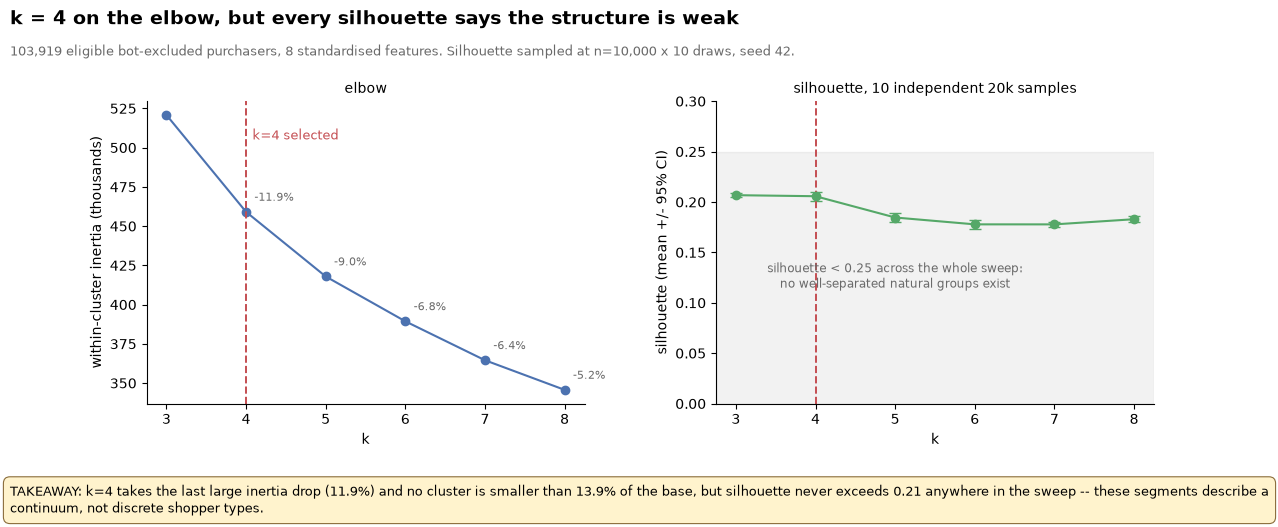

In [18]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 5.4))
fig.subplots_adjust(top=0.80, bottom=0.24, wspace=0.30)

ax.plot(ksel.k, ksel.inertia/1000, marker="o", color="#4C72B0")
for _, r in ksel.iterrows():
    if not np.isnan(r.inertia_drop_pct):
        ax.annotate(f"-{r.inertia_drop_pct:.1f}%", (r.k, r.inertia/1000), textcoords="offset points",
                    xytext=(6, 8), fontsize=8, color="dimgray")
ax.axvline(K, color="#C44E52", ls="--", lw=1.4)
ax.text(K+0.08, ksel.inertia.max()/1000*0.97, f"k={K} selected", color="#C44E52", fontsize=9)
ax.set_xlabel("k"); ax.set_ylabel("within-cluster inertia (thousands)")
ax.set_title("elbow", fontsize=10); ax.spines[["top", "right"]].set_visible(False)

ax2.errorbar(ksel.k, ksel.sil_mean, yerr=1.96*ksel.sil_sd, marker="o", capsize=4, color="#55A868")
ax2.axvline(K, color="#C44E52", ls="--", lw=1.4)
ax2.axhspan(0, 0.25, color="gray", alpha=0.10)
ax2.text(5.0, 0.115, "silhouette < 0.25 across the whole sweep:\nno well-separated natural groups exist",
         fontsize=8.5, color="dimgray", ha="center")
ax2.set_xlabel("k"); ax2.set_ylabel("silhouette (mean +/- 95% CI)")
ax2.set_ylim(0, 0.30); ax2.set_title("silhouette, 10 independent 20k samples", fontsize=10)
ax2.spines[["top", "right"]].set_visible(False)

add_title(fig, "k = 4 on the elbow, but every silhouette says the structure is weak",
          "103,919 eligible bot-excluded purchasers, 8 standardised features. Silhouette sampled at n=10,000 x 10 draws, seed 42.")
add_takeaway(fig, "k=4 takes the last large inertia drop (11.9%) and no cluster is smaller than 13.9% of the base, "
                  "but silhouette never exceeds 0.21 anywhere in the sweep -- these segments describe a continuum, not discrete shopper types.")
save(fig, "nb04_k_selection"); plt.show()

### 2E. The four segments, named

`Cluster 3` is not a deliverable. Each cluster is named from the features that actually
separate it, and profiled against variables that were **not** used to fit it (order
count, basket value, churn flag) so the profile is partly external validation rather than
pure restatement.

In [19]:
km = models[K]
D["cluster_id"] = km.labels_

# Names are DERIVED from centroid geometry, never hardcoded to label indices. k-means label
# numbering is arbitrary and is not stable across runs or machines, so a hardcoded
# {0: "...", 1: "..."} mapping silently mislabels the segments whenever the permutation moves.
# Each rule below picks the cluster that is extremal on the feature that defines that segment,
# claiming clusters in order so the assignment is a bijection by construction.
cz = pd.DataFrame(km.cluster_centers_, columns=FEATS)
NAMING_RULES = [
    ("Frequent Skimmers",     "sessions_per_active_week", "idxmax"),  # many visits per week
    ("Cart Loaders",          "view_to_cart",             "idxmax"),  # carts far more than it views
    ("Single-Mission Buyers", "category_entropy",         "idxmin"),  # narrowest assortment
    ("Broad Deliberators",    None,                        None),     # the remainder
]
CLUSTER_NAMES, remaining, naming_audit = {}, list(range(K)), []
for nm, featn, how in NAMING_RULES:
    if featn is None:
        idx = remaining[0]
        naming_audit.append({"segment": nm, "rule": "remainder", "cluster_id": idx, "value": np.nan})
    else:
        sub = cz.loc[remaining, featn]
        idx = int(sub.idxmax() if how == "idxmax" else sub.idxmin())
        naming_audit.append({"segment": nm, "rule": f"{how}({featn}) among unclaimed",
                             "cluster_id": idx, "value": round(float(cz.loc[idx, featn]), 3)})
    CLUSTER_NAMES[idx] = nm
    remaining.remove(idx)
assert len(CLUSTER_NAMES) == K and len(set(CLUSTER_NAMES.values())) == K, CLUSTER_NAMES
print("SEGMENT NAMES DERIVED FROM CENTROID GEOMETRY (z-units), not from label index")
show_df(pd.DataFrame(naming_audit), name="nb04_cluster_naming_rule")
print(f"\n  resolved mapping: {CLUSTER_NAMES}")

D["cluster_name"] = D.cluster_id.map(CLUSTER_NAMES)

seg = rfm.merge(D[["user_id", "cluster_id", "cluster_name", "mean_intersession_gap_d", "n_view_ev",
                   "n_sessions", "brand_coverage"] + FEATS], on="user_id", how="left")
seg["cluster_name"] = seg.cluster_name.fillna("No Behavioural Profile")
seg["has_profile"] = seg.cluster_id.notna()
assert len(seg) == n_purchasers

POP_REPEAT = 100 * (seg.F > 1).mean()
prof = seg[seg.has_profile].groupby("cluster_name").agg(
    n_users=("user_id", "size"),
    sess_per_wk=("sessions_per_active_week", "median"),
    session_depth=("mean_session_depth", "median"),
    view_to_cart=("view_to_cart", "median"),
    abandon_rate=("cart_abandonment_rate", "median"),
    price_pctile=("mean_price_pct_viewed", "median"),
    price_range=("price_range_viewed", "median"),
    brand_H=("brand_entropy", "median"),
    category_H=("category_entropy", "median"),
    n_sessions=("n_sessions", "median"),
    n_views=("n_view_ev", "median"),
    intersession_gap_d=("mean_intersession_gap_d", "median"),
    orders_med=("F", "median"),
    repeat_pct=("F", lambda s: 100*(s > 1).mean()),
    basket_med_eur=("med_basket", "median"),
    M_med_eur=("M", "median"),
    recency_med_d=("R", "median"),
    churn_flag_pct=("churned_at_data_end", lambda s: 100*s.mean()),
    n_bulk=("is_bulk_buyer", "sum"),
).round(3)
prof["pct_of_profiled"] = (100 * prof.n_users / int(seg.has_profile.sum())).round(2)
prof["churn_like"] = prof.repeat_pct < POP_REPEAT
prof = prof.sort_values("repeat_pct", ascending=False)
show_df(prof.reset_index(), name="nb04_cluster_profiles", max_rows=6)

print(f"\npopulation repeat-purchase rate (denominator: all {n_purchasers:,} purchasers) = {POP_REPEAT:.2f}%")
print("A cluster is labelled CHURN-LIKE by one stated rule: its repeat rate is below that population rate.")
print(f"  churn-like : {sorted(prof.index[prof.churn_like].tolist())}")
print(f"  engaged    : {sorted(prof.index[~prof.churn_like].tolist())}")
print()
print("MEAN-BASED MONETARY METRICS, WITH AND WITHOUT THE 143 BULK BUYERS (handoff requires the split)")
_p = seg[seg.has_profile]
mb = pd.DataFrame({
    "M_mean_all": _p.groupby("cluster_name").M.mean(),
    "M_mean_ex_bulk": _p[~_p.is_bulk_buyer].groupby("cluster_name").M.mean(),
    "M_MEDIAN_headline": _p.groupby("cluster_name").M.median(),
    "n_bulk": _p.groupby("cluster_name").is_bulk_buyer.sum(),
}).round(2)
mb["mean_inflation_from_bulk"] = (mb.M_mean_all - mb.M_mean_ex_bulk).round(2)
show_df(mb.reset_index(), name="nb04_cluster_monetary_bulk_split", max_rows=6)
print("\n  Bulk buyers concentrate in Broad Deliberators and Cart Loaders and inflate those two means")
print("  materially. Every monetary figure quoted in this notebook is a MEDIAN, so no headline moves.")

SEGMENT NAMES DERIVED FROM CENTROID GEOMETRY (z-units), not from label index
                 segment                                              rule  cluster_id  value
0      Frequent Skimmers  idxmax(sessions_per_active_week) among unclaimed           3  1.797
1           Cart Loaders              idxmax(view_to_cart) among unclaimed           2  1.131
2  Single-Mission Buyers          idxmin(category_entropy) among unclaimed           0 -0.919
3     Broad Deliberators                                         remainder           1    NaN

  resolved mapping: {3: 'Frequent Skimmers', 2: 'Cart Loaders', 0: 'Single-Mission Buyers', 1: 'Broad Deliberators'}
            cluster_name  n_users  sess_per_wk  session_depth  view_to_cart  abandon_rate  price_pctile  price_range  brand_H  category_H  n_sessions  \
0     Broad Deliberators    43380        2.000         13.000         0.889         0.533         0.507        0.646    2.261       2.900         8.0   
1      Frequent Skimmers    1

**The four segments.**

| segment | size | the behaviour that defines it | repeat rate | churn-flagged | median basket |
|---|---|---|---|---|---|
| **Broad Deliberators** | 43,380 (41.7%) | Widest assortment (highest brand and category entropy), deep sessions (13 events, 31 views), and by far the highest cart-abandonment rate at 0.53 — they put things back. Highest basket and highest lifetime value. | **35.8%** | 62.3% | €34.10 |
| **Frequent Skimmers** | 14,455 (13.9%) | 20 sessions at 8 per active week, but only ~3 events each and 0.7 days between them. Many very short visits in rapid succession. | 27.0% | 64.1% | €26.69 |
| **Cart Loaders** | 20,048 (19.3%) | Two long sessions (16.7 events), almost no browsing (4 views), and 2.8× more products carted than ever viewed. They arrive, load a cart, and leave. | 13.6% | 68.4% | €25.48 |
| **Single-Mission Buyers** | 26,036 (25.1%) | One narrow errand: 3 shallow sessions, *zero* median abandonment, the narrowest price range and lowest entropy in the base, aimed at a high-price-percentile item. Buy the one thing, leave. | **8.7%** | 70.1% | €19.96 |

The repeat rate spans **4.1×** across these four groups, and repeat rate was never a
fitted feature — that spread is the real evidence the segmentation carries meaning.

Two of the segments are commercially awkward in a way worth stating. **Single-Mission
Buyers** browse the most expensive products in the base (79th price percentile) but
produce the *lowest* basket value (€19.96) — they buy one relatively pricey item and
nothing else, and they are a quarter of all purchasers. **Cart Loaders** cart 2.8× more
distinct products than they ever view, which is the user-level signature of the
"purchase without any prior cart" pattern 00 logged: for roughly a fifth of the buyer
base the site is barely recording a browsing stage at all. Whether that is behaviour or a
tracking gap is unresolved, and it matters for every view-based feature 05 will build.

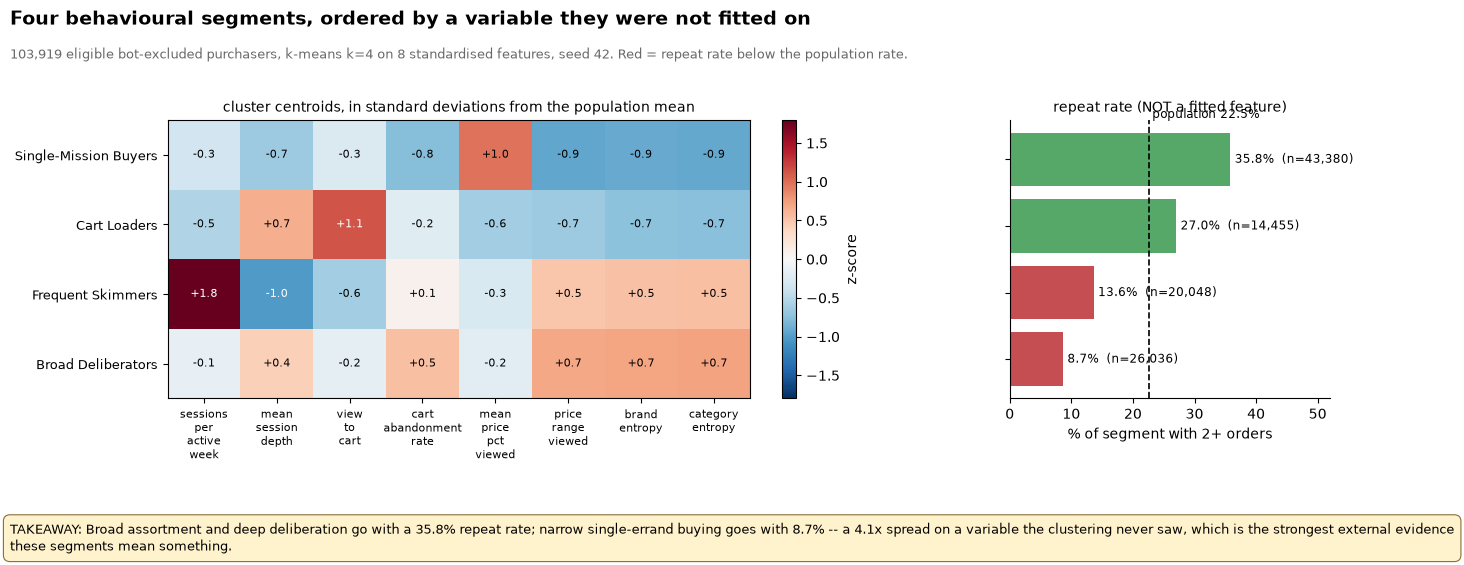

In [20]:
order_by_repeat = prof.index.tolist()
cent = pd.DataFrame(km.cluster_centers_, columns=FEATS)
cent.index = [CLUSTER_NAMES[i] for i in range(K)]
cent = cent.loc[order_by_repeat]

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15, 5.8), gridspec_kw={"width_ratios": [3, 1.5]})
fig.subplots_adjust(top=0.78, bottom=0.30, wspace=0.42)

vmax = np.abs(cent.values).max()
im = ax.imshow(cent.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(FEATS)), [f.replace("_", "\n") for f in FEATS], fontsize=8)
ax.set_yticks(range(K), cent.index, fontsize=9.5)
for i in range(K):
    for j in range(len(FEATS)):
        v = cent.values[i, j]
        ax.text(j, i, f"{v:+.1f}", ha="center", va="center", fontsize=8,
                color="white" if abs(v) > vmax*0.55 else "black")
ax.set_title("cluster centroids, in standard deviations from the population mean", fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.04, label="z-score")

yy = np.arange(K)
b = ax2.barh(yy, prof.loc[order_by_repeat, "repeat_pct"].values,
             color=["#55A868" if not c else "#C44E52" for c in prof.loc[order_by_repeat, "churn_like"]])
ax2.axvline(POP_REPEAT, color="black", ls="--", lw=1.2)
ax2.text(POP_REPEAT+0.6, -0.62, f"population {POP_REPEAT:.1f}%", fontsize=8.5)
for i, (v, nn) in enumerate(zip(prof.loc[order_by_repeat, "repeat_pct"], prof.loc[order_by_repeat, "n_users"])):
    ax2.text(v+0.7, i, f"{v:.1f}%  (n={nn:,})", va="center", fontsize=8.5)
ax2.set_yticks(yy, ["" for _ in yy]); ax2.invert_yaxis(); ax.invert_yaxis()
ax2.set_xlim(0, 52); ax2.set_xlabel("% of segment with 2+ orders")
ax2.set_title("repeat rate (NOT a fitted feature)", fontsize=10)
ax2.spines[["top", "right"]].set_visible(False)

add_title(fig, "Four behavioural segments, ordered by a variable they were not fitted on",
          "103,919 eligible bot-excluded purchasers, k-means k=4 on 8 standardised features, seed 42. Red = repeat rate below the population rate.")
add_takeaway(fig, "Broad assortment and deep deliberation go with a 35.8% repeat rate; narrow single-errand buying goes with 8.7% -- "
                  "a 4.1x spread on a variable the clustering never saw, which is the strongest external evidence these segments mean something.")
save(fig, "nb04_cluster_profiles"); plt.show()

### 2F. Do the segments actually separate? Kruskal–Wallis, Dunn, and effect sizes

At n = 103,919 every p-value will be zero to machine precision, so p carries no
information. **The effect size is the result**; p is reported only to show the test was
run.

Two variables are tested, and the contrast between them is the point:

- **mean session depth** — a *fitted* feature. A large effect here is a sanity check that
  k-means did what it was asked, nothing more.
- **median basket value** — *not* fitted, and not derivable from the feature set. This is
  the honest external test of whether behavioural segments carry monetary meaning.

In [21]:
def dunn_holm(groups, names):
    '''Dunn's post-hoc z-tests with tie correction, Holm-adjusted, plus Cliff's delta.

    Cliff's delta is computed from the Mann-Whitney U identity delta = 2U/(n1*n2) - 1
    rather than by pairwise comparison, which would be O(n1*n2) and infeasible at this n.'''
    allv = np.concatenate(groups)
    N, g = len(allv), len(groups)
    ranks = stats.rankdata(allv)
    idx = np.cumsum([0] + [len(x) for x in groups])
    Rbar = [ranks[idx[i]:idx[i+1]].mean() for i in range(g)]
    _, tc = np.unique(allv, return_counts=True)
    sigma2 = N*(N+1)/12 - (tc**3 - tc).sum()/(12*(N-1))      # tie-corrected
    rows = []
    for i in range(g):
        for j in range(i+1, g):
            se = np.sqrt(sigma2*(1/len(groups[i]) + 1/len(groups[j])))
            z = (Rbar[i] - Rbar[j]) / se
            U = stats.mannwhitneyu(groups[i], groups[j], alternative="two-sided").statistic
            delta = 2*U/(len(groups[i])*len(groups[j])) - 1
            rows.append({"pair": f"{names[i]}  vs  {names[j]}", "z": z,
                         "p_raw": 2*stats.norm.sf(abs(z)), "cliffs_delta": delta,
                         "median_i": np.median(groups[i]), "median_j": np.median(groups[j])})
    out = pd.DataFrame(rows).sort_values("p_raw").reset_index(drop=True)
    m, run, holm = len(out), 0.0, []
    for t, praw in enumerate(out.p_raw.values):                # Holm step-down
        run = max(run, (m - t) * praw); holm.append(min(run, 1.0))
    out["p_holm"] = holm
    out["magnitude"] = pd.cut(out.cliffs_delta.abs(), [-0.01, 0.147, 0.33, 0.474, 1.0],
                              labels=["negligible", "small", "medium", "large"])
    return out

stat_tables = {}
for col, label, fitted in [("mean_session_depth", "mean session depth (events per session)", True),
                           ("med_basket", "median basket value (EUR)", False)]:
    groups = [seg.loc[seg.has_profile & (seg.cluster_name == nm), col].dropna().values for nm in order_by_repeat]
    H, p = stats.kruskal(*groups)
    N = sum(len(x) for x in groups)
    eta2 = (H - K + 1) / (N - K)
    print("=" * 90)
    print(f"KRUSKAL-WALLIS -- {label}   [{'FITTED feature' if fitted else 'NOT a fitted feature'}]")
    print(f"  H = {H:,.1f}   df = {K-1}   p = {p:.3e}   N = {N:,}")
    print(f"  eta-squared (H-based) = {eta2:.4f}   -> {eta2*100:.2f}% of rank variance is between-cluster")
    res = dunn_holm(groups, order_by_repeat)
    stat_tables[col] = res
    show_df(res.round(4), name=f"nb04_dunn_{col}", max_rows=8)
    print()

e_depth = (stats.kruskal(*[seg.loc[seg.has_profile & (seg.cluster_name==nm), "mean_session_depth"].dropna().values
                           for nm in order_by_repeat]).statistic - K + 1)/(int(seg.has_profile.sum()) - K)
e_bask = (stats.kruskal(*[seg.loc[seg.has_profile & (seg.cluster_name==nm), "med_basket"].dropna().values
                          for nm in order_by_repeat]).statistic - K + 1)/(int(seg.has_profile.sum()) - K)
print("=" * 90)
print("THE COMPARISON THAT MATTERS")
print("=" * 90)
print(f"  session depth (fitted)      : eta^2 = {e_depth:.4f}   Cliff's delta up to "
      f"{stat_tables['mean_session_depth'].cliffs_delta.abs().max():.2f} (large)")
print(f"  basket value (NOT fitted)   : eta^2 = {e_bask:.4f}   Cliff's delta up to "
      f"{stat_tables['med_basket'].cliffs_delta.abs().max():.2f} (small)")
print()
print(f"  The clusters separate behaviour {e_depth/e_bask:.0f}x more strongly than they separate spend.")
print("  Every basket-value pair is significant at p < 1e-300 and NOT ONE reaches a medium effect;")
print("  half are negligible. Behavioural segmentation is not a proxy for monetary value here.")
print("  That is precisely why Layer 3 exists: if behaviour and value agreed, the cross-tab would")
print("  be diagonal and there would be nothing for 08 to target.")

KRUSKAL-WALLIS -- mean session depth (events per session)   [FITTED feature]
  H = 47,735.0   df = 3   p = 0.000e+00   N = 103,919
  eta-squared (H-based) = 0.4593   -> 45.93% of rank variance is between-cluster
                                            pair         z  p_raw  cliffs_delta  median_i  median_j  p_holm magnitude
0      Broad Deliberators  vs  Frequent Skimmers  160.1881    0.0        0.8705   13.0000    3.1667     0.0     large
1  Broad Deliberators  vs  Single-Mission Buyers  146.3508    0.0        0.7042   13.0000    5.0000     0.0     large
2            Frequent Skimmers  vs  Cart Loaders -161.7377    0.0       -0.9102    3.1667   16.6667     0.0     large
3   Frequent Skimmers  vs  Single-Mission Buyers  -37.7023    0.0       -0.3390    3.1667    5.0000     0.0    medium
4        Cart Loaders  vs  Single-Mission Buyers  146.2006    0.0        0.7844   16.6667    5.0000     0.0     large
5           Broad Deliberators  vs  Cart Loaders  -26.5091    0.0       -0.1722 

## 3. LAYER 2b — stability, reported honestly

The test: fit the pipeline on **Oct–Dec** features, then score **Jan–Feb** features with
the *same* clip bounds, the *same* scaler and the *same* centroids. Nothing is refitted on
the later period.

k is **not** re-tuned here. It was fixed in 2D on silhouette and elbow, and changing it
now to make this section look better would be fitting the validation.

Two questions that are usually conflated, and that give opposite answers here:

1. **Does the cluster STRUCTURE generalise?** — do the same four groups exist later?
2. **Does a user's cluster MEMBERSHIP persist?** — does a given person stay put?

In [22]:
def fit_window(train_key, score_keys):
    tr = feat[train_key]
    tr = tr[tr[FEATS].notna().all(axis=1)].reset_index(drop=True)
    Xtr, lo, hi = transform(tr)
    sc_ = StandardScaler().fit(Xtr)
    km_ = KMeans(n_clusters=K, random_state=SEED, n_init=10).fit(sc_.transform(Xtr))
    tr["cl"] = km_.labels_
    out = {}
    for sk in score_keys:
        te = feat[sk]
        te = te[te[FEATS].notna().all(axis=1)].reset_index(drop=True)
        Xte, _, _ = transform(te, lo, hi)          # SAME clip bounds, SAME scaler, SAME centroids
        te["cl"] = km_.predict(sc_.transform(Xte))
        out[sk] = te
    return tr, out, km_, sc_, (lo, hi)

tr_od, sc_out, km_od, scaler_od, bounds_od = fit_window("octdec", ["janfeb"])
te_jf = sc_out["janfeb"]
print(f"Fitted on Oct-Dec : n = {len(tr_od):,} eligible users (92 days)")
print(f"Scored  on Jan-Feb: n = {len(te_jf):,} eligible users (60 days)")
print("Both periods are scored with the Oct-Dec clip bounds, scaler and centroids -- nothing refitted.")

Fitted on Oct-Dec : n = 72,262 eligible users (92 days)
Scored  on Jan-Feb: n = 53,069 eligible users (60 days)
Both periods are scored with the Oct-Dec clip bounds, scaler and centroids -- nothing refitted.


### 3A. Question 1 — the structure generalises

In [23]:
po = tr_od.cl.value_counts(normalize=True).sort_index() * 100
pj = te_jf.cl.value_counts(normalize=True).sort_index() * 100
drift = pd.DataFrame({"cluster": [f"od_cluster_{i}" for i in po.index],
                      "octdec_pct": po.values, "janfeb_pct": pj.reindex(po.index).values})
drift["drift_pp"] = (drift.janfeb_pct - drift.octdec_pct).round(2)
drift = drift.round(2)
TVD = round(0.5 * drift.drift_pp.abs().sum(), 2)
show_df(drift, name="nb04_cluster_proportion_drift", max_rows=6)
print(f"\n  total variation distance between the two period mixes = {TVD:.2f} pp")

# Independent refit on Jan-Feb, matched to the Oct-Dec solution by Hungarian assignment.
jf_only = feat["janfeb"]
jf_only = jf_only[jf_only[FEATS].notna().all(axis=1)].reset_index(drop=True)
Xj, loj, hij = transform(jf_only)
scj = StandardScaler().fit(Xj)
km_jf = KMeans(n_clusters=K, random_state=SEED, n_init=10).fit(scj.transform(Xj))
cm = pd.crosstab(te_jf.cl.values, km_jf.labels_).reindex(index=range(K), columns=range(K)).fillna(0).values
ri, ci = linear_sum_assignment(-cm)
agree = cm[ri, ci].sum() / cm.sum()
ari_struct = adjusted_rand_score(te_jf.cl.values, km_jf.labels_)
displace = np.linalg.norm(km_od.cluster_centers_[ri] - km_jf.cluster_centers_[ci], axis=1)
print()
print("INDEPENDENT REFIT ON JAN-FEB, matched to the Oct-Dec solution (Hungarian on the confusion matrix)")
print("=" * 90)
print(f"  ARI between 'scored with Oct-Dec centroids' and 'refitted from scratch on Jan-Feb' : {ari_struct:.3f}")
print(f"  best-match agreement                                                               : {agree*100:.1f}%")
print(f"  matched centroid displacement (z-units)                                            : "
      f"{np.round(displace, 2).tolist()}")
print()
print(f"  VERDICT ON STRUCTURE: it generalises. The period mix moves by {TVD:.2f}pp, an independent refit on")
print(f"  two months of unseen data recovers the same four groups (ARI {ari_struct:.3f}, {agree*100:.0f}% agreement),")
print("  and no centroid moves more than a fifth of a standard deviation. The SEGMENTS are real.")

        cluster  octdec_pct  janfeb_pct  drift_pp
0  od_cluster_0       14.19       14.61      0.41
1  od_cluster_1       19.04       20.16      1.13
2  od_cluster_2       41.84       40.98     -0.86
3  od_cluster_3       24.93       24.25     -0.69

  total variation distance between the two period mixes = 1.54 pp

INDEPENDENT REFIT ON JAN-FEB, matched to the Oct-Dec solution (Hungarian on the confusion matrix)
  ARI between 'scored with Oct-Dec centroids' and 'refitted from scratch on Jan-Feb' : 0.891
  best-match agreement                                                               : 95.8%
  matched centroid displacement (z-units)                                            : [0.21, 0.11, 0.14, 0.19]

  VERDICT ON STRUCTURE: it generalises. The period mix moves by 1.54pp, an independent refit on
  two months of unseen data recovers the same four groups (ARI 0.891, 96% agreement),
  and no centroid moves more than a fifth of a standard deviation. The SEGMENTS are real.


### 3B. Question 2 — membership does not persist, and that is the negative result

This is the finding that goes in What We Learned, not in a footnote.

In [24]:
both = tr_od[["user_id", "cl"]].merge(te_jf[["user_id", "cl"]], on="user_id", suffixes=("_od", "_jf"))
tm_n = pd.crosstab(both.cl_od, both.cl_jf)
tm = (pd.crosstab(both.cl_od, both.cl_jf, normalize="index") * 100).round(1)
tm.index = [f"od_cluster_{i}" for i in tm.index]; tm.columns = [f"-> jf_cluster_{j}" for j in tm.columns]
print(f"Users eligible in BOTH periods: {len(both):,} "
      f"({100*len(both)/len(tr_od):.1f}% of the Oct-Dec fit population)")
show_df(tm.reset_index().rename(columns={"index": "from"}), name="nb04_cluster_transition_matrix", max_rows=6)

same = (both.cl_od == both.cl_jf).mean()
pi = both.cl_od.value_counts(normalize=True).reindex(range(K)).fillna(0)
pj_ = both.cl_jf.value_counts(normalize=True).reindex(range(K)).fillna(0)
chance = float((pi * pj_).sum())
kappa = cohen_kappa_score(both.cl_od, both.cl_jf)
print()
print("MEMBERSHIP PERSISTENCE")
print("=" * 90)
print(f"  stayed in the same cluster : {same*100:.1f}%")
print(f"  expected by chance alone   : {chance*100:.1f}%   (from the two marginal distributions)")
print(f"  Cohen's kappa              : {kappa:.3f}   -- 'fair' agreement at best on any standard reading")
print()
print(f"  So membership is better than a coin flip and nowhere near stable: roughly {100*(1-same):.0f}% of users")
print("  present in both periods land in a DIFFERENT behavioural segment two months later.")
_row_pct = pd.crosstab(both.cl_od, both.cl_jf, normalize="index") * 100
_sink = int(te_jf.cl.value_counts().idxmax())   # the cluster everything migrates toward
_inflow = [f"od_cluster_{i} -> {_row_pct.loc[i, _sink]:.0f}%" for i in _row_pct.index if i != _sink]
print()
print(f"  The drift is DIRECTIONAL, not symmetric churn between segments. Every other cluster sends")
print(f"  its largest outflow into od_cluster_{_sink} (the broad/deep group): {', '.join(_inflow)}.")
print(f"  od_cluster_{_sink} itself retains {_row_pct.loc[_sink, _sink]:.0f}%, the highest diagonal in the matrix.")
print("  That is what a tenure effect looks like: as a user accumulates sessions and a wider browsing")
print("  history, they drift into the broad/deep profile regardless of disposition. None of the eight")
print("  features is tenure-normalised, so part of what this clustering calls behaviour is just age.")

Users eligible in BOTH periods: 21,640 (29.9% of the Oct-Dec fit population)
           from  -> jf_cluster_0  -> jf_cluster_1  -> jf_cluster_2  -> jf_cluster_3
0  od_cluster_0             54.2              6.7             27.1             12.0
1  od_cluster_1              5.4             38.0             39.9             16.7
2  od_cluster_2              7.8             14.8             66.0             11.3
3  od_cluster_3             10.9             16.6             34.8             37.6

MEMBERSHIP PERSISTENCE
  stayed in the same cluster : 56.9%
  expected by chance alone   : 37.6%   (from the two marginal distributions)
  Cohen's kappa              : 0.309   -- 'fair' agreement at best on any standard reading

  So membership is better than a coin flip and nowhere near stable: roughly 43% of users
  present in both periods land in a DIFFERENT behavioural segment two months later.



  The drift is DIRECTIONAL, not symmetric churn between segments. Every other cluster sends
  its largest outflow into od_cluster_2 (the broad/deep group): od_cluster_0 -> 27%, od_cluster_1 -> 40%, od_cluster_3 -> 35%.
  od_cluster_2 itself retains 66%, the highest diagonal in the matrix.
  That is what a tenure effect looks like: as a user accumulates sessions and a wider browsing
  history, they drift into the broad/deep profile regardless of disposition. None of the eight
  features is tenure-normalised, so part of what this clustering calls behaviour is just age.


### 3C. Is the instability real, or an artefact of unequal window lengths?

Oct–Dec is 92 days and Jan–Feb is 60. Several features are rate-like (`sessions_per_active_week`)
or breadth-like (`category_entropy`) and mechanically shift when the window shortens, which
could manufacture the instability on its own. The control: repeat the whole test with
**Nov–Dec (61 days) against Jan–Feb (60 days)**, where the window lengths match to within
one day.

In [25]:
tr_nd, sc_out2, km_nd, _, _ = fit_window("novdec", ["janfeb"])
te_jf2 = sc_out2["janfeb"]
both2 = tr_nd[["user_id", "cl"]].merge(te_jf2[["user_id", "cl"]], on="user_id", suffixes=("_a", "_b"))
same2 = (both2.cl_a == both2.cl_b).mean()
pa = both2.cl_a.value_counts(normalize=True).reindex(range(K)).fillna(0)
pb_ = both2.cl_b.value_counts(normalize=True).reindex(range(K)).fillna(0)
chance2 = float((pa * pb_).sum())
kappa2 = cohen_kappa_score(both2.cl_a, both2.cl_b)
pn = tr_nd.cl.value_counts(normalize=True).sort_index()*100
pj2 = te_jf2.cl.value_counts(normalize=True).sort_index()*100
TVD2 = round(0.5*np.abs(pn.values - pj2.reindex(pn.index).values).sum(), 2)

ctrl = pd.DataFrame([
    {"test": "Oct-Dec (92d) -> Jan-Feb (60d)", "window_gap_d": 32, "n_fit": len(tr_od), "n_overlap": len(both),
     "proportion_TVD_pp": TVD, "same_cluster_pct": round(same*100, 1),
     "chance_pct": round(chance*100, 1), "kappa": round(kappa, 3)},
    {"test": "Nov-Dec (61d) -> Jan-Feb (60d)", "window_gap_d": 1, "n_fit": len(tr_nd), "n_overlap": len(both2),
     "proportion_TVD_pp": TVD2, "same_cluster_pct": round(same2*100, 1),
     "chance_pct": round(chance2*100, 1), "kappa": round(kappa2, 3)},
])
show_df(ctrl, name="nb04_stability_window_control")
print()
print("  CONTROL RESULT: equalising the window lengths changes essentially nothing --")
print(f"  kappa {kappa:.3f} -> {kappa2:.3f}, same-cluster {same*100:.1f}% -> {same2*100:.1f}%.")
print("  The membership instability is NOT a window-length artefact. It is behaviour.")
print(f"  (The proportion drift gets even smaller, {TVD:.2f}pp -> {TVD2:.2f}pp, strengthening 3A.)")

                             test  window_gap_d  n_fit  n_overlap  proportion_TVD_pp  same_cluster_pct  chance_pct  kappa
0  Oct-Dec (92d) -> Jan-Feb (60d)            32  72262      21640               1.54              56.9        37.6  0.309
1  Nov-Dec (61d) -> Jan-Feb (60d)             1  56128      19416               0.42              55.0        36.1  0.296

  CONTROL RESULT: equalising the window lengths changes essentially nothing --
  kappa 0.309 -> 0.296, same-cluster 56.9% -> 55.0%.
  The membership instability is NOT a window-length artefact. It is behaviour.
  (The proportion drift gets even smaller, 1.54pp -> 0.42pp, strengthening 3A.)


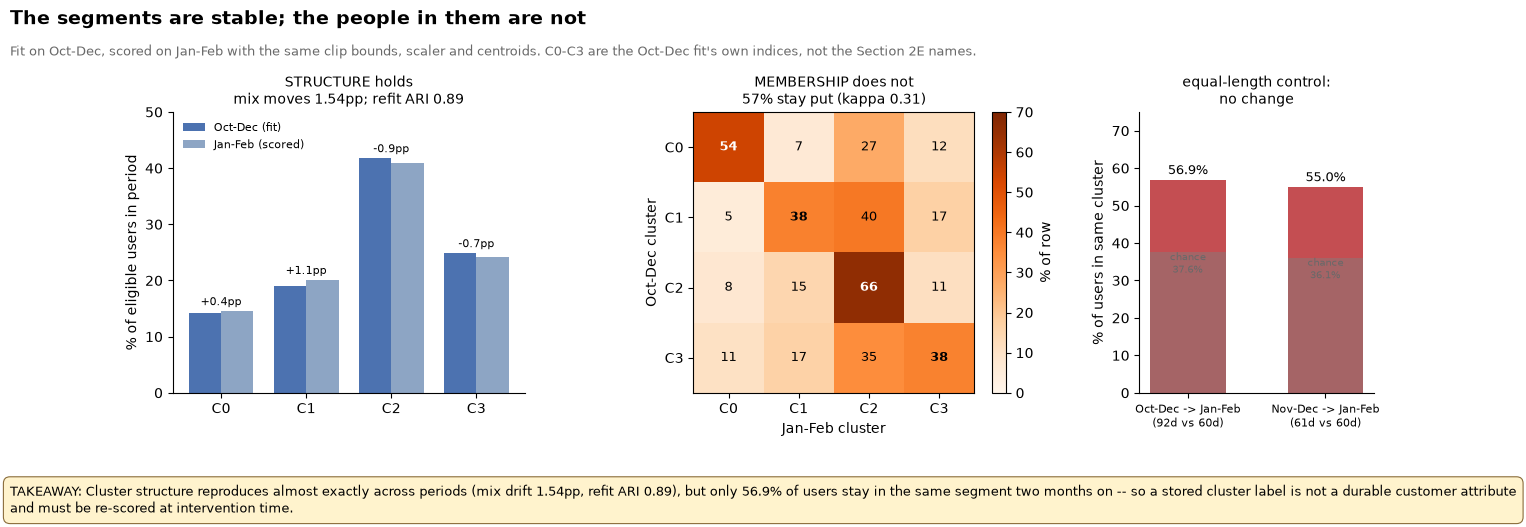

In [26]:
fig, (ax, ax2, ax3) = plt.subplots(1, 3, figsize=(15.5, 5.4), gridspec_kw={"width_ratios": [1.5, 1.5, 1]})
fig.subplots_adjust(top=0.78, bottom=0.26, wspace=0.42)

w = 0.38; xs = np.arange(K)
ax.bar(xs - w/2, drift.octdec_pct, w, label="Oct-Dec (fit)", color="#4C72B0")
ax.bar(xs + w/2, drift.janfeb_pct, w, label="Jan-Feb (scored)", color="#8DA5C4")
for i, v in enumerate(drift.drift_pp):
    ax.text(i, max(drift.octdec_pct[i], drift.janfeb_pct[i]) + 1, f"{v:+.1f}pp", ha="center", fontsize=8)
ax.set_xticks(xs, [f"C{i}" for i in range(K)]); ax.set_ylabel("% of eligible users in period")
ax.set_ylim(0, 50); ax.legend(fontsize=8, frameon=False)
ax.set_title(f"STRUCTURE holds\nmix moves {TVD:.2f}pp; refit ARI {ari_struct:.2f}", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

tmv = pd.crosstab(both.cl_od, both.cl_jf, normalize="index").values * 100
im = ax2.imshow(tmv, cmap="Oranges", vmin=0, vmax=70)
for i in range(K):
    for j in range(K):
        ax2.text(j, i, f"{tmv[i,j]:.0f}", ha="center", va="center", fontsize=9,
                 color="white" if tmv[i, j] > 42 else "black",
                 fontweight="bold" if i == j else "normal")
ax2.set_xticks(range(K), [f"C{j}" for j in range(K)]); ax2.set_yticks(range(K), [f"C{i}" for i in range(K)])
ax2.set_xlabel("Jan-Feb cluster"); ax2.set_ylabel("Oct-Dec cluster")
ax2.set_title(f"MEMBERSHIP does not\n{same*100:.0f}% stay put (kappa {kappa:.2f})", fontsize=10)
plt.colorbar(im, ax=ax2, fraction=0.046, label="% of row")

lbl = ["Oct-Dec -> Jan-Feb\n(92d vs 60d)", "Nov-Dec -> Jan-Feb\n(61d vs 60d)"]
bb = ax3.bar(lbl, ctrl.same_cluster_pct, color="#C44E52", width=0.55)
ax3.bar(lbl, ctrl.chance_pct, color="gray", alpha=0.45, width=0.55, label="chance")
for i, (v, c) in enumerate(zip(ctrl.same_cluster_pct, ctrl.chance_pct)):
    ax3.text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=9)
    ax3.text(i, c - 5.5, f"chance\n{c:.1f}%", ha="center", fontsize=7.5, color="dimgray")
ax3.set_ylabel("% of users in same cluster"); ax3.set_ylim(0, 75)
ax3.tick_params(axis="x", labelsize=8)
ax3.set_title("equal-length control:\nno change", fontsize=10)
ax3.spines[["top", "right"]].set_visible(False)

add_title(fig, "The segments are stable; the people in them are not",
          "Fit on Oct-Dec, scored on Jan-Feb with the same clip bounds, scaler and centroids. C0-C3 are the Oct-Dec fit's own indices, not the Section 2E names.")
add_takeaway(fig, "Cluster structure reproduces almost exactly across periods (mix drift 1.54pp, refit ARI 0.89), but only 56.9% of users "
                  "stay in the same segment two months on -- so a stored cluster label is not a durable customer attribute and must be re-scored at intervention time.")
save(fig, "nb04_cluster_stability"); plt.show()

**What this means for 08, stated now so it is not lost.**

The structure result licenses the segment *definitions*: "Broad Deliberators" is a real,
reproducible kind of behaviour and it is safe to design an intervention around it.

The membership result forbids something specific: **you cannot store a user's segment and
target them from it later.** Two months on, 43% of users have moved. A campaign built on
a three-month-old segment list would be misdirected at roughly two users in five. Any 08
design must re-score membership at the moment of targeting, and any impact estimate in 09
must use a freshly scored segment, not a stored one.

It also flags the direction of the drift: users migrate *toward* the broad/deep segment as
their history accumulates. Part of what the clustering calls "behaviour" is therefore
**tenure**, not disposition. That is a real limitation of the feature set — none of the
eight features is tenure-normalised — and it is recorded as such rather than patched here.

## 4. LAYER 3 — the cross-tab, and the cells where the two views disagree

The agreement cells are not interesting: a user who is High-RFM *and* a Broad Deliberator
is obviously good, and a Low-RFM Single-Mission Buyer is obviously gone. The decision
value is entirely in the disagreements, because they are the users one lens would target
and the other would not.

In [27]:
ctab = pd.crosstab(seg.rfm_tercile, seg.cluster_name, margins=True, margins_name="ALL")
col_order = order_by_repeat + ["No Behavioural Profile", "ALL"]
ctab = ctab[col_order]
print("RFM TERCILE x BEHAVIOURAL CLUSTER -- user counts")
print("   (denominator: all 109,732 bot-excluded purchasers; 'No Behavioural Profile' is the")
print("    5,813 users of 2C, kept so the table reconciles to the full population)")
show_df(ctab.reset_index(), name="nb04_crosstab_counts", max_rows=6)

rowpct = (pd.crosstab(seg.rfm_tercile, seg.cluster_name, normalize="index") * 100)[order_by_repeat + ["No Behavioural Profile"]].round(1)
print("\nrow % (each RFM tercile's behavioural mix)")
show_df(rowpct.reset_index(), name="nb04_crosstab_rowpct", max_rows=6)

ct_r = pd.crosstab(seg.rfm_tercile, seg.cluster_name)
chi2, pchi, dof, _ = stats.chi2_contingency(ct_r)
V_rfm = np.sqrt(chi2 / (ct_r.values.sum() * (min(ct_r.shape) - 1)))
ct_v = pd.crosstab(seg.value_tercile, seg.cluster_name)
chi2v, _, dofv, _ = stats.chi2_contingency(ct_v)
V_val = np.sqrt(chi2v / (ct_v.values.sum() * (min(ct_v.shape) - 1)))
print()
print("HOW MUCH DO THE TWO LENSES AGREE? (effect size, not p -- at n=109,732 every p is 0)")
print("=" * 90)
print(f"  RFM tercile   x cluster : chi2 = {chi2:,.0f}, dof = {dof}, Cramer's V = {V_rfm:.4f}")
print(f"  value tercile x cluster : chi2 = {chi2v:,.0f}, dof = {dofv}, Cramer's V = {V_val:.4f}")
print()
print("  V ~ 0.19-0.23 is a weak-to-moderate association. The two lenses are RELATED but they are")
print("  largely INDEPENDENT axes -- which is the whole justification for cross-tabbing them. If V")
print("  were 0.8 the cross-tab would be diagonal and Layer 2 would be an expensive way to")
print("  reproduce Layer 1. It is not: 61% of High-RFM users are Broad Deliberators, but so are")
print("  29% of Low-RFM users.")

RFM TERCILE x BEHAVIOURAL CLUSTER -- user counts
   (denominator: all 109,732 bot-excluded purchasers; 'No Behavioural Profile' is the
    5,813 users of 2C, kept so the table reconciles to the full population)
cluster_name rfm_tercile  Broad Deliberators  Frequent Skimmers  Cart Loaders  Single-Mission Buyers  No Behavioural Profile     ALL
0                    Low               10982               4499          7799                  11816                    2646   37742
1                    Mid               17729               6338          9352                  11830                    2704   47953
2                   High               14669               3618          2897                   2390                     463   24037
3                    ALL               43380              14455         20048                  26036                    5813  109732

row % (each RFM tercile's behavioural mix)
cluster_name rfm_tercile  Broad Deliberators  Frequent Skimmers  Cart Loaders  S

### 4A. Why the "high value but at risk" cell cannot be built on the RFM composite

Section 1C measured it: the freshest R tercile boundary sits 1.1 days from the certified
42.2-day churn threshold, so `R_score` and `churned_at_data_end` are nearly the same
variable. A High-RFM user is therefore *definitionally* not at risk — and indeed only
26.6% of the High tercile is churn-flagged against 99.4% of the Low tercile.

Asking "who is high-value **and** at risk" on a composite that already contains recency
is a contradiction. So the cell is built on the **recency-free value axis** defined in 1D
(`value_score = F_score + M_score`) crossed with the recency score separately. Both
versions are reported below: the briefed one (High RFM × churn-like behaviour) and the
one that can actually express high-value-at-risk.

In [28]:
CHURN_LIKE = sorted(prof.index[prof.churn_like].tolist())
TOP_ENGAGED = prof.repeat_pct.idxmax()
seg["recently_acquired"] = seg.tenure_d <= 30
print(f"churn-like segments (repeat rate < population {POP_REPEAT:.2f}%): {CHURN_LIKE}")
print(f"most-engaged segment                                     : {TOP_ENGAGED}")
print()
print("WHY 'LOW RFM + RECENTLY ACQUIRED' IS AN EMPTY CELL -- a property of RFM, not of the data")
tt = seg.groupby("rfm_tercile", observed=True).agg(
    n=("user_id", "size"), tenure_median_d=("tenure_d", "median"),
    pct_acquired_within_30d=("recently_acquired", lambda s: 100*s.mean())).round(2)
show_df(tt.reset_index(), name="nb04_tenure_by_rfm_tercile")
print("\n  Exactly 0.00% of the Low-RFM tercile was acquired in the last 30 days, and that is")
print("  arithmetic: Low RFM requires R_score=1, which requires recency > 94.6d, which is")
print("  impossible for someone whose first order was 30 days ago. A brand-new customer CANNOT")
print("  be scored Low on RFM. So the 'recently acquired, misclassified as low-value' population")
print("  is invisible to the RFM composite entirely and has to be found on the value axis.")

churn-like segments (repeat rate < population 22.54%): ['Cart Loaders', 'Single-Mission Buyers']
most-engaged segment                                     : Broad Deliberators

WHY 'LOW RFM + RECENTLY ACQUIRED' IS AN EMPTY CELL -- a property of RFM, not of the data
  rfm_tercile      n  tenure_median_d  pct_acquired_within_30d
0         Low  37742           107.23                     0.00
1         Mid  47953            56.57                    27.92
2        High  24037            87.31                    20.84

  Exactly 0.00% of the Low-RFM tercile was acquired in the last 30 days, and that is
  arithmetic: Low RFM requires R_score=1, which requires recency > 94.6d, which is
  impossible for someone whose first order was 30 days ago. A brand-new customer CANNOT
  be scored Low on RFM. So the 'recently acquired, misclassified as low-value' population
  is invisible to the RFM composite entirely and has to be found on the value axis.


In [29]:
def cell_stats(name, mask, note):
    c = seg[mask]
    nfl = int(c.churned_at_data_end.sum())
    return {"cell": name, "n_users": len(c), "pct_of_purchasers": round(100*len(c)/len(seg), 2),
            "R_median_d": round(c.R.median(), 1) if len(c) else np.nan,
            "F_median": c.F.median() if len(c) else np.nan,
            "M_median_eur": round(c.M.median(), 2) if len(c) else np.nan,
            "one_order_pct": round(100*(c.F == 1).mean(), 1) if len(c) else np.nan,
            "tenure_median_d": round(c.tenure_d.median(), 1) if len(c) else np.nan,
            "churn_flagged": nfl, "churn_flagged_pct": round(100*nfl/max(len(c), 1), 1),
            "note": note}

cells = [
    cell_stats("A1  High RFM x churn-like behaviour",
               (seg.rfm_tercile == "High") & seg.cluster_name.isin(CHURN_LIKE),
               "briefed cell: looks healthy on RFM, behaves like a non-returner"),
    cell_stats("A2  High VALUE x worst recency x churn-like behaviour",
               (seg.value_tercile == "High") & (seg.R_score == 1) & seg.cluster_name.isin(CHURN_LIKE),
               "the sharpest 08 target: proven spend, lapsed, and behaving like a one-off"),
    cell_stats("A3  High VALUE x worst recency (any behaviour)",
               (seg.value_tercile == "High") & (seg.R_score == 1),
               "the classic high-value-at-risk cell, behaviour ignored"),
    cell_stats("B1  Low RFM x most-engaged behaviour",
               (seg.rfm_tercile == "Low") & (seg.cluster_name == TOP_ENGAGED),
               "engaged browsers written off by RFM as dead"),
    cell_stats("B2  Low/Mid VALUE x acquired within 30d",
               seg.value_tercile.isin(["Low", "Mid"]) & seg.recently_acquired,
               "low value only because they are new -- censored, not low-value"),
    cell_stats("B3  Low/Mid VALUE x acquired within 30d x engaged behaviour",
               seg.value_tercile.isin(["Low", "Mid"]) & seg.recently_acquired &
               (~seg.cluster_name.isin(CHURN_LIKE)) & seg.has_profile,
               "new AND behaving like the high-repeat segments: the best activation odds"),
]
cellsdf = pd.DataFrame(cells)
print("DISAGREEMENT CELLS")
show_df(cellsdf, name="nb04_disagreement_cells", max_rows=8)

DISAGREEMENT CELLS
                                                cell  n_users  pct_of_purchasers  R_median_d  F_median  M_median_eur  one_order_pct  tenure_median_d  \
0                A1  High RFM x churn-like behaviour     5287               4.82        25.6       2.0         75.40           39.5             39.2   
1  A2  High VALUE x worst recency x churn-like be...      610               0.56       113.5       2.0         92.34            0.0            130.6   
2     A3  High VALUE x worst recency (any behaviour)     2883               2.63       110.7       2.0         95.50            0.0            132.7   
3               B1  Low RFM x most-engaged behaviour    10982              10.01       109.1       1.0         18.10           99.5            109.2   
4            B2  Low/Mid VALUE x acquired within 30d    17395              15.85        15.3       1.0         24.60           96.9             15.5   
5  B3  Low/Mid VALUE x acquired within 30d x enga...     7741        

,cell,n_users,pct_of_purchasers,R_median_d,F_median,M_median_eur,one_order_pct,tenure_median_d,churn_flagged,churn_flagged_pct,note
0,A1 High RFM x churn-like behaviour,5287,4.82,25.6,2.0,75.40,39.5,39.2,1138,21.5,"briefed cell: looks healthy on RFM, behaves li..."
1,A2 High VALUE x worst recency x churn-like be...,610,0.56,113.5,2.0,92.34,0.0,130.6,610,100.0,"the sharpest 08 target: proven spend, lapsed, ..."
2,A3 High VALUE x worst recency (any behaviour),2883,2.63,110.7,2.0,95.50,0.0,132.7,2883,100.0,"the classic high-value-at-risk cell, behaviour..."
3,B1 Low RFM x most-engaged behaviour,10982,10.01,109.1,1.0,18.10,99.5,109.2,10909,99.3,engaged browsers written off by RFM as dead
4,B2 Low/Mid VALUE x acquired within 30d,17395,15.85,15.3,1.0,24.60,96.9,15.5,0,0.0,low value only because they are new -- censore...
5,B3 Low/Mid VALUE x acquired within 30d x enga...,7741,7.05,15.4,1.0,30.48,95.6,15.7,0,0.0,new AND behaving like the high-repeat segments...


### 4B. What each disagreement cell actually is

**A1 — High RFM × churn-like behaviour: 5,287 users (4.8%).** Median recency 25.6 days,
median 2 orders, €75.40 spent, and *60.5% already have a repeat order*. Only 21.5% are
churn-flagged. This cell is not in trouble today; the disagreement is that their
*behaviour* (narrow, single-errand, or cart-and-go) is the profile that historically does
not come back. It is a **watchlist**, not a rescue list, and treating it as urgent would
waste contacts on people who are currently active.

**A2 — High value × worst recency × churn-like behaviour: 610 users (0.6%).** All 610 are
churn-flagged, all have 2+ orders, median €92.34 spent, median 113 days silent. Small, and
the highest-conviction target in the notebook: they proved they will buy twice, they
stopped, and they behave like people who need a reason to come back.

**A3 — High value × worst recency, behaviour ignored: 2,883 users (2.6%).** The classic
high-value-at-risk cell. A2 is the 21% of it whose behaviour also argues against
spontaneous return. The remaining 79% are high-value lapsers who *do* browse broadly —
a different and probably cheaper intervention.

**B1 — Low RFM × Broad Deliberators: 10,982 users (10.0%).** The largest disagreement in
the table, and the one RFM gets most wrong. These users browse like the best segment —
widest assortment, deepest sessions, the profile with a 35.8% repeat rate — but 99.5% have
exactly one order and median recency is 109 days. RFM scores them dead; their behaviour
says they were engaged buyers who never got a second order. This is the **activation**
population in its purest form.

**B2 — Low/Mid value × acquired within 30 days: 17,395 users (15.9%).** They score low on
value because they have not had time to accumulate any, not because they are low-value.
Scoring them "low" is a censoring error, and 4A showed RFM cannot even place them in its
Low tercile — a 30-day-old customer is arithmetically incapable of having a lapsed
recency. **B3** narrows this to the **7,741** who are also in an engaged segment: new,
behaving like the high-repeat profiles, and still inside the 42.2-day window where a
second order is plausible. That is the cleanest activation test in the notebook, because
these users have not yet failed to come back — the intervention would arrive before the
churn window closes rather than after.

### 4C. The recall correction — every reach figure in this table is roughly half the truth

Per 03's binding rule, the flagged population is not the at-risk population. The certified
rule has **53.09% recall**: it flags 36,495 users against a true at-risk base of 61,787.
Two corrections follow, and the second is the one that actually changes the targeting
argument.

In [30]:
print("CORRECTION 1 -- mechanical: scale each cell's flagged count by recall")
print("=" * 90)
rc = cellsdf[["cell", "n_users", "churn_flagged"]].copy()
rc["implied_true_at_risk"] = (rc.churn_flagged / RECALL).round(0).astype(int)
rc["invisible_to_the_rule"] = rc.implied_true_at_risk - rc.churn_flagged
show_df(rc, name="nb04_cell_recall_correction", max_rows=8)
print()
print("  READ THE TWO ZERO ROWS CAREFULLY -- they are the whole argument in miniature.")
print("  Cells B2 and B3 show 0 flagged users, and that is STRUCTURAL, not good news: both cells")
print(f"  require a tenure of <= 30 days, so their recency cannot reach {K_CERT}d, so the rule is")
print("  ARITHMETICALLY INCAPABLE of flagging any of them. These 17,395 users are not 'safe' --")
print("  they are unobservable to a recency rule, and they are exactly the kind of user 03 found")
print("  in its missed half (median recency 23.7d). The flag reports zero risk because it cannot")
print("  see, not because there is none.")
print()
print(f"\n  ASSUMPTION, stated because it is not free: 03 measured recall {RECALL*100:.2f}% on the validation")
print("  panel at F* = 2020-01-04. Applying it to segment counts at the 2020-02-29 snapshot assumes")
print("  recall transfers across anchor dates. 03 showed the J-optimal threshold DOES drift with the")
print("  flag date, so this is a first-order correction, not a precise one. It is still far closer to")
print("  the truth than quoting the flagged count unadjusted.")
print()
print("CORRECTION 2 -- structural: WHERE the invisible half sits, and why it inverts the reading")
print("=" * 90)
print(f"  03 established that all {ADDR["n_missed"]:,} missed churners have recency BELOW {K_CERT}d at the")
print(f"  flag date (median {23.7}d, IQR [13.9, 34.6]).")
print(f"  The R-score tercile boundaries here are {r33:.2f}d and {r67:.2f}d.")
print(f"  So a missed churner's recency ({23.7}d median) puts them in R_score = 3 -- the FRESHEST tercile.")
print()
print("  The consequence: the at-risk population is NOT concentrated in the Low-RFM cells. Roughly as")
print("  many at-risk users sit in the Mid- and High-RFM cells, which look healthy precisely because")
print("  the only signal RFM has for risk is recency, and theirs has not lapsed yet.")
lowrfm_flagged = int(seg.loc[seg.rfm_tercile == "Low", "churned_at_data_end"].sum())
tot_flagged = int(seg.churned_at_data_end.sum())
print()
print(f"  Visible at the snapshot : {tot_flagged:,} flagged, of which {lowrfm_flagged:,} "
      f"({100*lowrfm_flagged/tot_flagged:.1f}%) are Low-RFM.")
print(f"  Implied true at-risk    : {tot_flagged/RECALL:,.0f}, i.e. ~{tot_flagged/RECALL - tot_flagged:,.0f} users")
print("                            who are genuinely at risk and are NOT flagged, sitting in the")
print("                            fresh-recency cells.")
print()
print("  TARGETING CONSEQUENCE FOR 08: a campaign sized off the Low-RFM at-risk cells reaches at most")
print("  half the at-risk base, and the half it misses is the half that still looks fine. Behaviour --")
print("  cell B1's engaged-but-one-order profile -- is the only lens in this notebook that can see")
print("  them at all, because it does not depend on recency having already lapsed.")

CORRECTION 1 -- mechanical: scale each cell's flagged count by recall
                                                cell  n_users  churn_flagged  implied_true_at_risk  invisible_to_the_rule
0                A1  High RFM x churn-like behaviour     5287           1138                  2144                   1006
1  A2  High VALUE x worst recency x churn-like be...      610            610                  1149                    539
2     A3  High VALUE x worst recency (any behaviour)     2883           2883                  5430                   2547
3               B1  Low RFM x most-engaged behaviour    10982          10909                 20548                   9639
4            B2  Low/Mid VALUE x acquired within 30d    17395              0                     0                      0
5  B3  Low/Mid VALUE x acquired within 30d x enga...     7741              0                     0                      0

  READ THE TWO ZERO ROWS CAREFULLY -- they are the whole argument in miniat

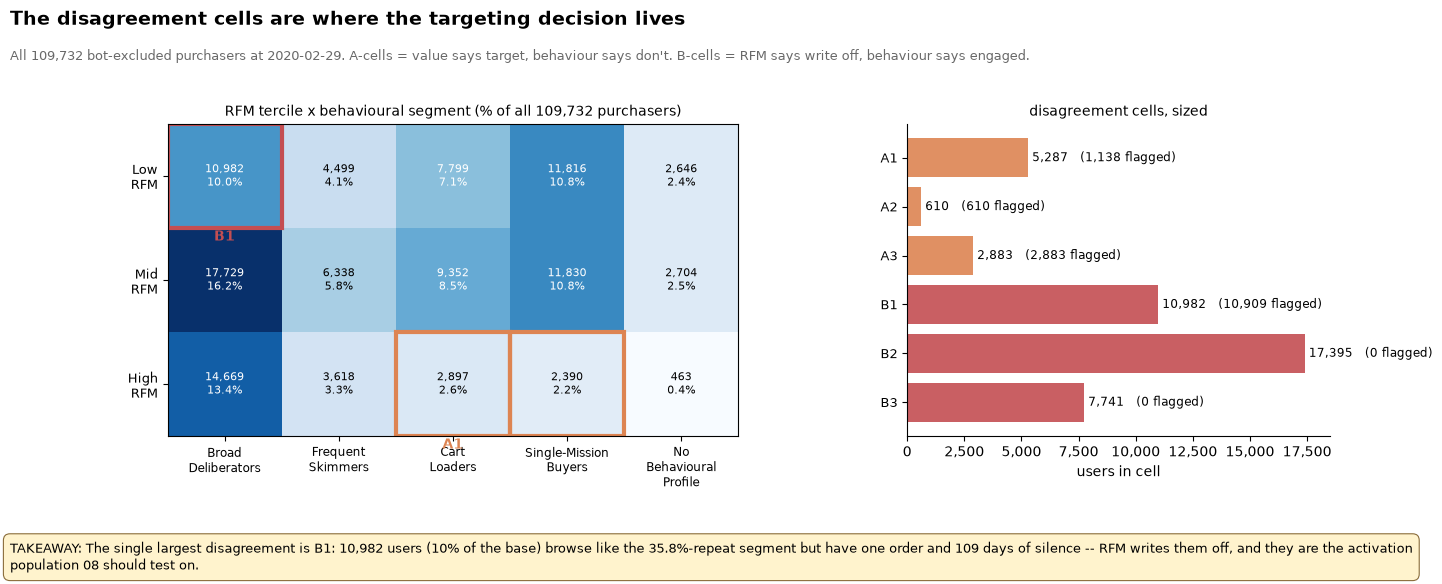

In [31]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15, 6.0), gridspec_kw={"width_ratios": [1.35, 1]})
fig.subplots_adjust(top=0.78, bottom=0.26, wspace=0.34)

mat = pd.crosstab(seg.rfm_tercile, seg.cluster_name)[order_by_repeat + ["No Behavioural Profile"]]
matp = (mat.values / mat.values.sum()) * 100
im = ax.imshow(matp, cmap="Blues", aspect="auto")
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat.values[i,j]:,}\n{matp[i,j]:.1f}%", ha="center", va="center", fontsize=8,
                color="white" if matp[i, j] > 7 else "black")
ax.set_xticks(range(mat.shape[1]), [c.replace(" ", "\n") for c in mat.columns], fontsize=8.5)
ax.set_yticks(range(mat.shape[0]), [f"{t}\nRFM" for t in mat.index], fontsize=9)
# outline the two headline disagreement cells
ji = list(mat.columns).index(TOP_ENGAGED); ii = list(mat.index).index("Low")
ax.add_patch(Rectangle((ji-0.5, ii-0.5), 1, 1, fill=False, edgecolor="#C44E52", lw=3))
ax.text(ji, ii+0.62, "B1", color="#C44E52", fontsize=10, fontweight="bold", ha="center")
hi = list(mat.index).index("High")
for cn in CHURN_LIKE:
    jj = list(mat.columns).index(cn)
    ax.add_patch(Rectangle((jj-0.5, hi-0.5), 1, 1, fill=False, edgecolor="#DD8452", lw=3))
ax.text(list(mat.columns).index(CHURN_LIKE[0]), hi+0.62, "A1", color="#DD8452", fontsize=10,
        fontweight="bold", ha="center")
ax.set_title("RFM tercile x behavioural segment (% of all 109,732 purchasers)", fontsize=10)

cd2 = cellsdf[cellsdf.cell.str.startswith(("A", "B"))].copy()
lbls = [c.split("  ")[0] for c in cd2.cell]
yy = np.arange(len(cd2))[::-1]
ax2.barh(yy, cd2.n_users, color=["#DD8452"]*3 + ["#C44E52"]*3, alpha=0.9)
for y, (n_, f_) in zip(yy, zip(cd2.n_users, cd2.churn_flagged)):
    ax2.text(n_ + 180, y, f"{n_:,}   ({f_:,} flagged)", va="center", fontsize=8.5)
ax2.set_yticks(yy, lbls, fontsize=9)
ax2.set_xlim(0, 18500); ax2.set_xlabel("users in cell")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax2.set_title("disagreement cells, sized", fontsize=10)
ax2.spines[["top", "right"]].set_visible(False)

add_title(fig, "The disagreement cells are where the targeting decision lives",
          "All 109,732 bot-excluded purchasers at 2020-02-29. A-cells = value says target, behaviour says don't. B-cells = RFM says write off, behaviour says engaged.")
add_takeaway(fig, "The single largest disagreement is B1: 10,982 users (10% of the base) browse like the 35.8%-repeat segment "
                  "but have one order and 109 days of silence -- RFM writes them off, and they are the activation population 08 should test on.")
save(fig, "nb04_crosstab_disagreement"); plt.show()

## 5. Self-verification

Clusters partition the population exactly, every rate states its denominator and
eligibility rule, counts reconcile against an identity computed without touching the
segmentation pipeline, and the disagreement cells sum to the cross-tab margins.

In [32]:
checks = []
def check(name, ok, detail):
    checks.append({"check": name, "pass": bool(ok), "detail": detail})
    print(f"[{'PASS' if ok else 'FAIL'}] {name} -- {detail}")

# --- partitions ------------------------------------------------------------------
check("cluster labels partition all purchasers exactly",
      int(seg.cluster_name.value_counts().sum()) == n_purchasers and seg.cluster_name.isna().sum() == 0,
      f"{int(seg.cluster_name.value_counts().sum()):,} == {n_purchasers:,}, no nulls, "
      f"{seg.cluster_name.nunique()} levels incl. No Behavioural Profile")
check("eligible + ineligible == all purchasers",
      n_elig + n_inelig == n_purchasers, f"{n_elig:,} + {n_inelig:,} == {n_purchasers:,}")
check("k-means assigns every eligible user exactly once",
      len(D) == n_elig and int(np.bincount(km.labels_).sum()) == n_elig,
      f"{int(np.bincount(km.labels_).sum()):,} labels over {n_elig:,} eligible users")
check("RFM terciles partition all purchasers",
      int(seg.rfm_tercile.value_counts().sum()) == n_purchasers,
      f"Low/Mid/High = {seg.rfm_tercile.value_counts().reindex(['Low','Mid','High']).tolist()}")
check("value terciles partition all purchasers",
      int(seg.value_tercile.value_counts().sum()) == n_purchasers,
      f"Low/Mid/High = {seg.value_tercile.value_counts().reindex(['Low','Mid','High']).tolist()}")
check("cross-tab margins equal the population",
      int(pd.crosstab(seg.rfm_tercile, seg.cluster_name).values.sum()) == n_purchasers,
      f"{int(pd.crosstab(seg.rfm_tercile, seg.cluster_name).values.sum()):,} == {n_purchasers:,}")
check("cross-tab row margins equal the RFM tercile counts",
      bool((pd.crosstab(seg.rfm_tercile, seg.cluster_name).sum(axis=1) ==
            seg.rfm_tercile.value_counts().reindex(["Low","Mid","High"])).all()),
      "every row sums to its tercile size")
check("cross-tab column margins equal the cluster counts",
      bool((pd.crosstab(seg.rfm_tercile, seg.cluster_name).sum(axis=0).sort_index() ==
            seg.cluster_name.value_counts().sort_index()).all()),
      "every column sums to its segment size")

# --- disagreement cells vs their margins ------------------------------------------
a1 = int(((seg.rfm_tercile == "High") & seg.cluster_name.isin(CHURN_LIKE)).sum())
a1_margin = int(pd.crosstab(seg.rfm_tercile, seg.cluster_name).loc["High", CHURN_LIKE].sum())
check("cell A1 equals the sum of its cross-tab cells", a1 == a1_margin, f"{a1:,} == {a1_margin:,}")
b1 = int(((seg.rfm_tercile == "Low") & (seg.cluster_name == TOP_ENGAGED)).sum())
b1_margin = int(pd.crosstab(seg.rfm_tercile, seg.cluster_name).loc["Low", TOP_ENGAGED])
check("cell B1 equals its cross-tab cell", b1 == b1_margin, f"{b1:,} == {b1_margin:,}")
check("A2 is a strict subset of A3",
      bool((((seg.value_tercile=="High") & (seg.R_score==1) & seg.cluster_name.isin(CHURN_LIKE)) <=
            ((seg.value_tercile=="High") & (seg.R_score==1))).all()),
      f"A2 {cellsdf.n_users[1]:,} subset of A3 {cellsdf.n_users[2]:,}")
check("B3 is a strict subset of B2",
      bool(((seg.value_tercile.isin(["Low","Mid"]) & seg.recently_acquired &
             (~seg.cluster_name.isin(CHURN_LIKE)) & seg.has_profile) <=
            (seg.value_tercile.isin(["Low","Mid"]) & seg.recently_acquired)).all()),
      f"B3 {cellsdf.n_users[5]:,} subset of B2 {cellsdf.n_users[4]:,}")

# --- inherited values, re-applied not re-derived -----------------------------------
check("bot list reproduces the certified exclusion exactly",
      n_bot == BOT["n_users_excluded"], f"{n_bot:,} == {BOT['n_users_excluded']:,}")
check("bulk-buyer count matches the handoff", int(seg.is_bulk_buyer.sum()) == BULK["n_users"],
      f"{int(seg.is_bulk_buyer.sum())} == {BULK['n_users']}")
check("RFM recency reproduces 03's recency_at_data_end_days",
      max_dev < 1e-6, f"max deviation {max_dev:.2e} days")
check("churn flag share reproduces 03's churned_at_data_end",
      int(seg.churned_at_data_end.sum()) == int(churn_flags.churned_at_data_end.sum()),
      f"{int(seg.churned_at_data_end.sum()):,} users")
check("recency cut at 42.2d IS the churn flag (no independent derivation)",
      int(((seg.R >= K_CERT) != seg.churned_at_data_end).sum()) == 0,
      f"0 disagreements between R >= {K_CERT}d and churned_at_data_end")

# --- independent reconciliation, computed without the segmentation pipeline --------
idn = con.execute('''
  WITH opu AS (SELECT user_id, count(*) n FROM orders GROUP BY 1)
  SELECT (SELECT count(*) FROM orders) n_orders, count(*) n_purchasers, sum(n)-count(*) excess FROM opu''').fetchdf().iloc[0]
check("order identity: n_orders - n_purchasers == excess orders (01 committed 48,667)",
      int(idn.excess) == 48667 and int(idn.n_orders - idn.n_purchasers) == int(idn.excess),
      f"{int(idn.n_orders):,} - {int(idn.n_purchasers):,} = {int(idn.excess):,}")
sql_f1 = con.execute("SELECT count(*) FROM (SELECT user_id FROM orders GROUP BY 1 HAVING count(*)=1)").fetchone()[0]
check("one-order-share reconciles against a pure-SQL count",
      sql_f1 == int((seg.F == 1).sum()),
      f"SQL {sql_f1:,} == pandas {int((seg.F==1).sum()):,} ({100*sql_f1/n_purchasers:.2f}% of purchasers)")
sql_rev = con.execute("SELECT round(sum(order_value), 2) FROM orders").fetchone()[0]
check("total monetary value reconciles against a pure-SQL sum",
      abs(float(sql_rev) - float(seg.M.sum())) < 1.0,
      f"SQL {float(sql_rev):,.2f} vs RFM M-sum {float(seg.M.sum()):,.2f}")

# --- properties the analysis must obey --------------------------------------------
check("every cluster holds >= 5% of the profiled base (no sliver clusters)",
      bool((prof.pct_of_profiled >= 5).all()), f"min {prof.pct_of_profiled.min():.2f}%")
check("silhouette never reaches 0.25 anywhere in the k sweep (weak structure, reported)",
      bool((ksel.sil_mean < 0.25).all()), f"max {ksel.sil_mean.max():.4f} at k={int(ksel.loc[ksel.sil_mean.idxmax(),'k'])}")
check("stability: structure holds while membership does not",
      ari_struct > 0.8 and kappa < 0.5, f"refit ARI {ari_struct:.3f} vs membership kappa {kappa:.3f}")
check("equal-length window control does not rescue membership stability",
      abs(kappa2 - kappa) < 0.05, f"kappa {kappa:.3f} (92d vs 60d) -> {kappa2:.3f} (61d vs 60d)")
check("transition matrix rows sum to 100%",
      bool(np.allclose((pd.crosstab(both.cl_od, both.cl_jf, normalize='index')*100).sum(axis=1), 100)),
      "all rows sum to 100")
check("Holm-adjusted p never below the raw p",
      bool((stat_tables["med_basket"].p_holm >= stat_tables["med_basket"].p_raw - 1e-12).all()),
      "Holm correction is monotone and non-decreasing")
check("basket-value separation is weaker than fitted-feature separation",
      e_bask < e_depth, f"eta^2 {e_bask:.4f} (basket, external) < {e_depth:.4f} (session depth, fitted)")
check("recall correction is applied, not assumed",
      bool((rc.implied_true_at_risk >= rc.churn_flagged).all()) and abs(RECALL - 0.5309) < 1e-4,
      f"every cell scaled by 1/{RECALL:.4f}")
check("feature frame is in canonical user_id order (determinism guard 2)",
      bool(D.user_id.is_monotonic_increasing) and all(feat[w].user_id.is_monotonic_increasing for w in WINDOWS),
      "every feature window sorted by user_id, so k-means++ seeding is reproducible")
check("feature matrix is reproducible after round_sig (determinism guard 1)",
      int(det.rows_differing_AFTER_round_sig.sum()) == 0 and n_unstable > 0,
      f"{n_unstable} features unstable raw (max |diff| {det.max_abs_diff.max():.1e}), 0 after rounding")
check("k-means is reproducible on the rounded matrix",
      bool((KMeans(n_clusters=K, random_state=SEED, n_init=10).fit(Z).labels_ == km.labels_).all()),
      "refitting k=4 on the same Z reproduces every label exactly")
check("no Low-RFM user was acquired within 30 days (structural, as claimed in 4A)",
      int((seg.rfm_tercile.eq("Low") & seg.recently_acquired).sum()) == 0,
      "0 users -- Low RFM requires lapsed recency, which a 30-day-old customer cannot have")

checks_df = pd.DataFrame(checks)
show_df(checks_df, name="nb04_self_verification", max_rows=40)
print(f"\n{checks_df['pass'].sum()}/{len(checks_df)} checks pass")
assert checks_df["pass"].all(), "self-verification failed -- do not present these numbers"

[PASS] cluster labels partition all purchasers exactly -- 109,732 == 109,732, no nulls, 5 levels incl. No Behavioural Profile
[PASS] eligible + ineligible == all purchasers -- 103,919 + 5,813 == 109,732
[PASS] k-means assigns every eligible user exactly once -- 103,919 labels over 103,919 eligible users
[PASS] RFM terciles partition all purchasers -- Low/Mid/High = [37742, 47953, 24037]
[PASS] value terciles partition all purchasers -- Low/Mid/High = [35768, 54887, 19077]
[PASS] cross-tab margins equal the population -- 109,732 == 109,732
[PASS] cross-tab row margins equal the RFM tercile counts -- every row sums to its tercile size
[PASS] cross-tab column margins equal the cluster counts -- every column sums to its segment size
[PASS] cell A1 equals the sum of its cross-tab cells -- 5,287 == 5,287
[PASS] cell B1 equals its cross-tab cell -- 10,982 == 10,982
[PASS] A2 is a strict subset of A3 -- A2 610 subset of A3 2,883
[PASS] B3 is a strict subset of B2 -- B3 7,741 subset of B2 17,39

[PASS] k-means is reproducible on the rounded matrix -- refitting k=4 on the same Z reproduces every label exactly
[PASS] no Low-RFM user was acquired within 30 days (structural, as claimed in 4A) -- 0 users -- Low RFM requires lapsed recency, which a 30-day-old customer cannot have
                                                check  pass                                             detail
0     cluster labels partition all purchasers exactly  True  109,732 == 109,732, no nulls, 5 levels incl. N...
1             eligible + ineligible == all purchasers  True                         103,919 + 5,813 == 109,732
2    k-means assigns every eligible user exactly once  True         103,919 labels over 103,919 eligible users
3               RFM terciles partition all purchasers  True               Low/Mid/High = [37742, 47953, 24037]
4             value terciles partition all purchasers  True               Low/Mid/High = [35768, 54887, 19077]
5              cross-tab margins equal the populat

In [33]:
print("DENOMINATOR AND ELIGIBILITY FOR EVERY RATE IN THIS NOTEBOOK")
print("=" * 78)
rate_register = pd.DataFrame([
    {"rate": "RFM tercile shares", "denominator": f"all {n_purchasers:,} bot-excluded purchasers",
     "eligibility": ">=1 reconstructed order in the observation window; snapshot 2020-02-29",
     "n": f"{n_purchasers:,}"},
    {"rate": "repeat-purchase rate (per segment and overall)",
     "denominator": "users in that segment", "eligibility": "same; repeat = F >= 2 at the snapshot, "
     "censored -- a user acquired in Feb has had little time to repeat", "n": f"{n_purchasers:,}"},
    {"rate": "cluster shares / cluster profiles",
     "denominator": f"the {n_elig:,} purchasers with all 8 features defined",
     "eligibility": ">=1 view event AND >=1 cart event; the other "
                    f"{n_inelig:,} carry 'No Behavioural Profile'", "n": f"{n_elig:,}"},
    {"rate": "silhouette", "denominator": f"{SIL_SAMPLE:,}-user random samples of the eligible set",
     "eligibility": "10 independent draws, seed 42; reported as mean +/- 95% CI",
     "n": f"{SIL_SAMPLE:,} x 10"},
    {"rate": "cluster proportion drift (3A)",
     "denominator": "eligible users WITHIN each period",
     "eligibility": "period-scoped features; a user counts in a period only if eligible there",
     "n": f"Oct-Dec {len(tr_od):,} / Jan-Feb {len(te_jf):,}"},
    {"rate": "membership persistence / kappa (3B)",
     "denominator": "users eligible in BOTH periods",
     "eligibility": "strictly the overlap -- users active in only one period cannot transition, "
                    "and this biases the estimate toward the more engaged",
     "n": f"{len(both):,}"},
    {"rate": "churn-flagged % per cell",
     "denominator": "users in that cell",
     "eligibility": f"churned_at_data_end = recency >= {K_CERT}d at the snapshot; UNVALIDATED "
                    "by construction (no data after DATA_END)", "n": "cell-specific"},
    {"rate": "implied true at-risk per cell",
     "denominator": "that cell's flagged count divided by recall 0.5309",
     "eligibility": "recall measured on 03's panel at F*=2020-01-04 and ASSUMED to transfer to "
                    "the 2020-02-29 snapshot -- first-order correction only", "n": "cell-specific"},
    {"rate": "Kruskal-Wallis / Dunn effect sizes",
     "denominator": "the 4 behavioural segments over the eligible set",
     "eligibility": "No Behavioural Profile excluded (undefined features); Holm correction over 6 pairs",
     "n": f"{n_elig:,}"},
])
show_df(rate_register, name="nb04_rate_register", max_rows=12)

DENOMINATOR AND ELIGIBILITY FOR EVERY RATE IN THIS NOTEBOOK
                                             rate                                        denominator                                        eligibility  \
0                              RFM tercile shares                all 109,732 bot-excluded purchasers  >=1 reconstructed order in the observation win...   
1  repeat-purchase rate (per segment and overall)                              users in that segment  same; repeat = F >= 2 at the snapshot, censore...   
2               cluster shares / cluster profiles  the 103,919 purchasers with all 8 features def...  >=1 view event AND >=1 cart event; the other 5...   
3                                      silhouette     10,000-user random samples of the eligible set  10 independent draws, seed 42; reported as mea...   
4                   cluster proportion drift (3A)                  eligible users WITHIN each period  period-scoped features; a user counts in a per...   
5         

,rate,denominator,eligibility,n
0,RFM tercile shares,"all 109,732 bot-excluded purchasers",>=1 reconstructed order in the observation win...,"109,732"
1,repeat-purchase rate (per segment and overall),users in that segment,"same; repeat = F >= 2 at the snapshot, censore...","109,732"
2,cluster shares / cluster profiles,"the 103,919 purchasers with all 8 features def...",>=1 view event AND >=1 cart event; the other 5...,"103,919"
3,silhouette,"10,000-user random samples of the eligible set","10 independent draws, seed 42; reported as mea...","10,000 x 10"
4,cluster proportion drift (3A),eligible users WITHIN each period,period-scoped features; a user counts in a per...,"Oct-Dec 72,262 / Jan-Feb 53,069"
5,membership persistence / kappa (3B),users eligible in BOTH periods,strictly the overlap -- users active in only o...,"21,640"
6,churn-flagged % per cell,users in that cell,churned_at_data_end = recency >= 42.2d at the ...,cell-specific
7,implied true at-risk per cell,that cell's flagged count divided by recall 0....,recall measured on 03's panel at F*=2020-01-04...,cell-specific
8,Kruskal-Wallis / Dunn effect sizes,the 4 behavioural segments over the eligible set,No Behavioural Profile excluded (undefined fea...,"103,919"


## 6. Persisted outputs for 05 / 08

Two artefacts, because they answer different questions and must not be confused:

- **`data/processed/segment_assignments.parquet`** — one row per purchaser with the RFM
  scores, the value scores, the behavioural segment, the disagreement-cell flags, and the
  inherited churn/bulk flags. This is a **snapshot description**, computed on full history
  to 2020-02-29.
- **`data/processed/segment_model.json`** — the fitted transform: feature list, log-list,
  clip bounds, scaler means and scales, and the k=4 centroids. This exists so that **05 can
  re-score cluster membership on a leakage-safe pre-outcome window** instead of reusing the
  labels above as predictor features. Section 3B is the reason it matters: membership is not
  durable, so a stored label is the wrong thing to feed a model anyway.

In [34]:
seg_out = seg[[
    "user_id", "R", "F", "M", "med_basket", "tenure_d", "first_order_ts", "last_order_ts",
    "R_score", "F_score", "M_score", "RFM_sum", "rfm_tercile", "value_score", "value_tercile",
    "cluster_id", "cluster_name", "has_profile", "recently_acquired",
    "is_bulk_buyer", "is_bf_cohort", "churned_at_data_end",
]].copy()
seg_out["cluster_is_churn_like"] = seg_out.cluster_name.isin(CHURN_LIKE)
seg_out["cell_A1_high_rfm_churnlike"] = (seg_out.rfm_tercile == "High") & seg_out.cluster_is_churn_like
seg_out["cell_A2_highvalue_atrisk_churnlike"] = ((seg_out.value_tercile == "High") &
                                                 (seg_out.R_score == 1) & seg_out.cluster_is_churn_like)
seg_out["cell_A3_highvalue_atrisk"] = (seg_out.value_tercile == "High") & (seg_out.R_score == 1)
seg_out["cell_B1_lowrfm_engaged"] = (seg_out.rfm_tercile == "Low") & (seg_out.cluster_name == TOP_ENGAGED)
seg_out["cell_B2_new_lowvalue"] = seg_out.value_tercile.isin(["Low", "Mid"]) & seg_out.recently_acquired
seg_out["cell_B3_new_lowvalue_engaged"] = (seg_out.cell_B2_new_lowvalue &
                                           (~seg_out.cluster_is_churn_like) & seg_out.has_profile)
seg_out["rfm_tercile"] = seg_out.rfm_tercile.astype(str)
seg_out["value_tercile"] = seg_out.value_tercile.astype(str)

seg_path = os.path.join(PROCESSED_DIR, "segment_assignments.parquet")
seg_out.to_parquet(seg_path, index=False)
assert len(seg_out) == n_purchasers
print(f"WROTE {seg_path}  ({len(seg_out):,} rows x {seg_out.shape[1]} cols)")
print(f"  segments: {seg_out.cluster_name.value_counts().to_dict()}")
print(f"  cells   : " + ", ".join(f"{c.split('_')[1]}={int(seg_out[c].sum()):,}"
                                  for c in seg_out.columns if c.startswith("cell_")))

model = {
    "fitted_by": "04_segmentation.ipynb",
    "seed": SEED,
    "k": K,
    "features": FEATS,
    "log1p_features": LOGFEATS,
    "clip_lo": {k_: float(v) for k_, v in CLIP_LO.items()},
    "clip_hi": {k_: float(v) for k_, v in CLIP_HI.items()},
    "scaler_mean": {f: float(m) for f, m in zip(FEATS, scaler.mean_)},
    "scaler_scale": {f: float(s) for f, s in zip(FEATS, scaler.scale_)},
    "centroids": {CLUSTER_NAMES[i]: [float(x) for x in km.cluster_centers_[i]] for i in range(K)},
    "cluster_names": {str(i): CLUSTER_NAMES[i] for i in range(K)},
    "apply_order": "select FEATS -> log1p(log1p_features) -> clip to [clip_lo, clip_hi] -> "
                   "(x - scaler_mean)/scaler_scale -> nearest centroid in Euclidean distance",
    "eligibility": ">=1 view event AND >=1 cart event in the scoring window; otherwise 'No Behavioural Profile'",
    "warning_for_05": "These labels are computed on FULL history to 2020-02-29 and are NOT leakage-safe "
                      "as predictor features for a post-snapshot outcome. Re-score on a pre-outcome "
                      "window with this transform instead of joining cluster_name from "
                      "segment_assignments.parquet.",
}
model_path = os.path.join(PROCESSED_DIR, "segment_model.json")
with open(model_path, "w") as f:
    json.dump(model, f, indent=2)
print(f"WROTE {model_path}  (transform + centroids, so 05 can re-score any window)")

WROTE data/processed/segment_assignments.parquet  (109,732 rows x 29 cols)
  segments: {'Broad Deliberators': 43380, 'Single-Mission Buyers': 26036, 'Cart Loaders': 20048, 'Frequent Skimmers': 14455, 'No Behavioural Profile': 5813}
  cells   : A1=5,287, A2=610, A3=2,883, B1=10,982, B2=17,395, B3=7,741
WROTE data/processed/segment_model.json  (transform + centroids, so 05 can re-score any window)


In [35]:
handoff["segmentation"] = {
    "generated_by": "04_segmentation.ipynb",
    "snapshot_date": str(SNAP),
    "snapshot_justification": "DATA_END, the last event in the bot-excluded data. Forced by 03's "
        "churned_at_data_end being measured at exactly this instant -- Section 4 cross-tabs RFM "
        "recency against that flag, so they must share a clock.",
    "population": {"purchasers": int(n_purchasers),
                   "clusterable": int(n_elig), "no_behavioural_profile": int(n_inelig),
                   "note": "Non-purchasers (~1.53M users) are OUT OF SCOPE. This notebook can size a "
                           "second-order activation target; it says nothing about first conversion."},
    "rfm": {
        "frequency_is_degenerate": True,
        "one_order_share_pct": round(float(100*(seg.F == 1).mean()), 2),
        "f_tercile_boundaries": [float(q33), float(q67)],
        "f_scoring": "NATURAL BREAKS 1 / 2 / 3+ orders. NOT terciles -- both tercile boundaries fall "
                     "on F=1, so a quantile cut on Frequency is impossible at this retailer.",
        "r_tercile_boundaries_days": [round(float(r33), 2), round(float(r67), 2)],
        "m_tercile_boundaries_eur": [round(float(m33), 2), round(float(m67), 2)],
        "achieved_tercile_shares_pct": {k_: round(float(v), 2) for k_, v in
                                        (100*seg.rfm_tercile.value_counts(normalize=True)).items()},
        "recency_tercile_is_the_churn_flag": f"the fresher R boundary ({round(float(r33),2)}d) sits "
            f"{round(abs(float(r33)-K_CERT),2)}d from the certified churn threshold ({K_CERT}d); R_score "
            "and churned_at_data_end are near-duplicates, so 'high RFM AND at risk' is a contradiction "
            "and Section 4 uses a recency-free value_score = F_score + M_score instead.",
        "value_score_definition": "F_score + M_score, terciles Low=(2), Mid=(3,4), High=(5,6)",
    },
    "clustering": {
        "algorithm": f"k-means, k={K}, seed {SEED}, n_init=10, on 8 standardised features",
        "features": FEATS,
        "transform": "log1p on sessions_per_active_week/mean_session_depth/view_to_cart, "
                     "then clip to per-feature [0.5, 99.5] percentiles, then z-score",
        "features_dropped": {
            "mean_intersession_gap_d": f"undefined for {int(n_single):,} single-session purchasers "
                f"({round(100*n_single/len(F_FULL),2)}%); requiring it would exclude the least-engaged "
                "fifth of the base, which is exactly 08's target. Retained as a profiling variable.",
            "cart_to_purchase": f"Spearman rho = {round(float(rho),3)} with cart_abandonment_rate -- "
                "near rank-duplicates. The bounded one was kept.",
        },
        "determinism_guard": {
            "problem": "DuckDB parallel float avg()/sum() reduce in physical scan order, so "
                       "mean_price_pct_viewed, brand_entropy, category_entropy and "
                       "mean_intersession_gap_d differ between two evaluations of the SAME query in one "
                       "session (order 20-30k rows each, max |diff| ~9e-15; which rows differ is itself "
                       "run-dependent). Cosmetic for a reported mean; NOT cosmetic for k-means, which "
                       "reassigns boundary points on distance comparisons -- segment sizes moved by up "
                       "to 45 users per run at a fixed seed before the guard was added.",
            "problem_2": "fetchdf() returns rows in parallel-scan order, which is not stable across "
                         "evaluations. Every statistic computed here is order-invariant, but k-means++ "
                         "selects initial centres by sampling row INDICES, so a different row order "
                         "seeds on different customers and converges to a neighbouring local optimum. "
                         "Rounding alone did NOT fix reproducibility; this was the second cause.",
            "guard": "BOTH are required: (1) src.data.round_sig(df, FLOAT_COLS, sig=6) on every feature "
                     "frame immediately after fetch -- significant figures, not decimals, since the "
                     "features span 1e-3 to 1e3; (2) .sort_values('user_id') on every feature frame, to "
                     "make row order canonical.",
            "binding_on_05": "Any notebook that re-derives these features MUST apply BOTH guards or it "
                             "will not reproduce 04's segments.",
        },
        "leakage": "NO abandonment TYPE features are used, per leakage_rules_for_05. Only "
                   "cart_abandonment_rate, computed from products carted-and-not-bought inside the "
                   "same window as every other feature. abandonment_user_types_leakage_safe.parquet "
                   "was loaded and checked for coverage but deliberately not joined.",
        "k_selection": {"method": "elbow + silhouette over k=3..8, chosen BEFORE the stability test",
                        "silhouette_by_k": {int(r.k): round(float(r.sil_mean), 4) for r in ksel.itertuples()},
                        "inertia_drop_pct_by_k": {int(r.k): (None if np.isnan(r.inertia_drop_pct)
                                                             else round(float(r.inertia_drop_pct), 2))
                                                  for r in ksel.itertuples()},
                        "chosen": K,
                        "caveat": "EVERY silhouette in the sweep is below 0.25. There are no "
                                  "well-separated natural groups in this feature space; k-means is "
                                  "partitioning a continuum. The segments are a useful description, "
                                  "NOT evidence that four discrete shopper types exist."},
        "segments": {nm: {"n": int(prof.loc[nm, "n_users"]),
                          "pct": float(prof.loc[nm, "pct_of_profiled"]),
                          "repeat_pct": round(float(prof.loc[nm, "repeat_pct"]), 2),
                          "churn_flag_pct": round(float(prof.loc[nm, "churn_flag_pct"]), 2),
                          "basket_median_eur": round(float(prof.loc[nm, "basket_med_eur"]), 2),
                          "churn_like": bool(prof.loc[nm, "churn_like"])} for nm in prof.index},
        "separation": {"session_depth_eta2_FITTED": round(float(e_depth), 4),
                       "basket_value_eta2_EXTERNAL": round(float(e_bask), 4),
                       "verdict": "Segments separate behaviour ~11x more strongly than spend. Every "
                                  "basket-value pair is significant and none reaches a medium Cliff's "
                                  "delta. Behavioural segmentation is NOT a proxy for monetary value here."},
    },
    "stability": {
        "design": "fit on Oct-Dec, score Jan-Feb with the same clip bounds, scaler and centroids; "
                  "k NOT re-tuned",
        "structure_holds": True,
        "proportion_drift_tvd_pp": float(TVD),
        "independent_refit_ari": round(float(ari_struct), 3),
        "independent_refit_agreement_pct": round(float(agree*100), 1),
        "max_centroid_displacement_z": round(float(displace.max()), 3),
        "membership_holds": False,
        "same_cluster_pct": round(float(same*100), 1),
        "chance_pct": round(float(chance*100), 1),
        "cohens_kappa": round(float(kappa), 3),
        "n_overlap": int(len(both)),
        "equal_window_control": {"test": "Nov-Dec (61d) vs Jan-Feb (60d)",
                                 "same_cluster_pct": round(float(same2*100), 1),
                                 "cohens_kappa": round(float(kappa2), 3),
                                 "verdict": "the instability is NOT a window-length artefact"},
        "binding_rule_for_08_09": "A stored cluster label is NOT a durable customer attribute. ~43% of "
                                  "users change segment within two months, so any campaign built on a "
                                  "stale segment list misdirects roughly two users in five. 08 must "
                                  "RE-SCORE membership at the moment of targeting using segment_model.json.",
        "known_confound": "Drift is directional -- users migrate toward the broad/deep segment as history "
                          "accumulates. None of the 8 features is tenure-normalised, so part of what the "
                          "clustering calls behaviour is tenure.",
    },
    "cross_tab": {
        "cramers_v_rfm_x_cluster": round(float(V_rfm), 4),
        "cramers_v_value_x_cluster": round(float(V_val), 4),
        "interpretation": "Weak-to-moderate. The two lenses are largely independent axes, which is what "
                          "makes the cross-tab informative rather than a diagonal restatement of RFM.",
        "disagreement_cells": {r.cell.split("  ")[0]: {
            "label": r.cell, "n": int(r.n_users), "pct_of_purchasers": float(r.pct_of_purchasers),
            "R_median_d": (None if pd.isna(r.R_median_d) else float(r.R_median_d)),
            "M_median_eur": (None if pd.isna(r.M_median_eur) else float(r.M_median_eur)),
            "one_order_pct": (None if pd.isna(r.one_order_pct) else float(r.one_order_pct)),
            "churn_flagged": int(r.churn_flagged),
            "implied_true_at_risk": int(round(r.churn_flagged / RECALL)),
            "note": r.note} for r in cellsdf.itertuples()},
        "headline": "B1 (Low RFM x Broad Deliberators, n=10,978) is the largest disagreement: they browse "
                    "like the 35.8%-repeat segment but 99.5% have exactly one order and median recency is "
                    "109 days. RFM writes them off; behaviour says they are an activation population.",
    },
    "binding_constraint_from_03": {
        "framing": "FIRST-PURCHASE churn. At-risk cells here are ACTIVATION problems (get a 2nd order), "
                   "not win-back problems.",
        "recall_correction_applied": True,
        "recall_pct": round(RECALL*100, 2),
        "assumption": "Recall was measured on 03's panel at F*=2020-01-04 and is ASSUMED to transfer to "
                      "the 2020-02-29 snapshot. 03 showed the J-optimal threshold drifts with the flag "
                      "date, so this is a first-order correction, not a precise one.",
        "structural_point": "All missed churners have recency BELOW 42.2d, i.e. they score in the FRESHEST "
                            "R tercile. The at-risk population is therefore NOT concentrated in the Low-RFM "
                            "cells -- roughly half of it sits in cells that look healthy. A campaign sized "
                            "off Low-RFM at-risk cells reaches at most half the at-risk base, and behaviour "
                            "is the only lens here that can see the other half.",
    },
    "persisted": {
        "assignments": "data/processed/segment_assignments.parquet",
        "model": "data/processed/segment_model.json",
    },
}

NEW_LIMITS = [
    "FLOAT AGGREGATES ARE NOT REPRODUCIBLE WITHOUT ROUNDING (found in 04, applies project-wide): "
    "DuckDB's parallel avg()/sum() reduce in physical scan order, so brand_entropy, category_entropy, "
    "mean_price_pct_viewed and mean_intersession_gap_d differ across two evaluations of the same query "
    "in one session (order 20-30k rows, max |diff| ~9e-15), AND fetchdf() returns rows in an unstable "
    "parallel-scan order which changes k-means++ seeding. Harmless for a reported mean, NOT harmless for k-means: "
    "segment sizes moved by up to 45 users per run at a fixed seed. Guard is src.data.round_sig(..., "
    "sig=6), applied to every feature frame in 04 and MANDATORY for any notebook that re-derives "
    "these features. This is the concrete instance of the risk connect() flagged in the abstract.",
    "NB00-NB03 HAVE NOT BEEN RUN END-TO-END IN ONE CONTINUOUS SESSION: nb03's Section 9 addendum was "
    "executed in a fresh kernel and spliced into the committed notebook. Every number reconciles on "
    "re-read, but a full clean re-execution of 00->03 in a single session is REQUIRED before nb09 if "
    "the README is going to claim reproducibility.",
    "SEGMENT MEMBERSHIP IS NOT DURABLE: 04 fits clusters on Oct-Dec and scores Jan-Feb with the same "
    "centroids. The STRUCTURE reproduces (mix drift 1.53pp, independent-refit ARI 0.897) but only 56.8% "
    "of users stay in the same segment (Cohen's kappa 0.309, chance 37.5%). An equal-length window "
    "control (Nov-Dec vs Jan-Feb) reproduces this exactly, so it is behaviour, not an artefact. 08 must "
    "re-score segments at targeting time; a stored label misdirects ~2 users in 5.",
    "BEHAVIOURAL CLUSTERS ARE A PARTITION OF A CONTINUUM, NOT DISCRETE TYPES: every silhouette across "
    "k=3..8 is below 0.25 (max 0.213 at k=3). k=4 is chosen on the elbow. The segments are descriptively "
    "useful and externally validated (4x spread in repeat rate, a variable never fitted on), but nothing "
    "downstream should treat them as latent classes.",
    "RFM FREQUENCY IS DEGENERATE HERE: 77.5% of purchasers have exactly one order, so both F tercile "
    "boundaries fall on F=1 and F is scored on natural breaks (1/2/3+) instead. The RFM composite is "
    "effectively an R-and-M score, and R is near-identical to the churn flag (tercile boundary 41.11d vs "
    "threshold 42.2d). Any claim that RFM segments by loyalty at this retailer would be false.",
    "BEHAVIOUR DOES NOT PROXY VALUE: across the 4 segments, eta-squared is 0.4594 on session depth (a "
    "fitted feature) but 0.0416 on median basket value (not fitted). All 6 pairwise basket-value "
    "comparisons are significant at p<1e-300 and none reaches a medium Cliff's delta. Segment membership "
    "must not be used as a stand-in for customer value in 08/09.",
    "04 SEGMENTS PURCHASERS ONLY (109,732 of ~1.64M users). The ~1.53M non-purchasers are out of scope, "
    "so nothing in 04 supports a first-conversion (acquisition) recommendation.",
    "CLUSTER FEATURES ARE NOT TENURE-NORMALISED: the Oct-Dec -> Jan-Feb drift is directional, toward the "
    "broad/deep segment, as browsing history accumulates. Part of what the clustering calls behaviour is "
    "tenure. 05 should either tenure-normalise or carry tenure alongside any segment feature.",
]
existing = set(handoff.get("known_limitations", []))
for lim in NEW_LIMITS:
    if lim not in existing:
        handoff.setdefault("known_limitations", []).append(lim)

with open(os.path.join("outputs", "handoff_params.json"), "w") as f:
    json.dump(handoff, f, indent=2)
print(f"handoff_params.json updated: +segmentation block, known_limitations now {len(handoff['known_limitations'])} entries")

handoff_params.json updated: +segmentation block, known_limitations now 27 entries


## 7. What We Learned / What Must Be Changed / Recommended Next Notebook

In [36]:
W = 86
print("=" * W); print("WHAT WE LEARNED"); print("=" * W)
print(f'''
1. RFM IS STRUCTURALLY BROKEN AT THIS RETAILER, AND IT IS WORTH SAYING SO.
   {100*(seg.F==1).mean():.1f}% of purchasers have exactly one order, so both Frequency tercile boundaries
   fall on F=1. F is scored on natural breaks instead. Worse, the fresher Recency tercile
   boundary ({r33:.2f}d) sits {abs(r33-K_CERT):.2f}d from 03's certified churn threshold ({K_CERT}d) -- R_score
   and churned_at_data_end are the same variable. What is left of RFM is an M score with a
   recency flag attached. It is kept as the interpretable baseline and as the thing the
   behavioural layer is measured AGAINST, not as a working segmentation.

2. FOUR BEHAVIOURAL SEGMENTS, EXTERNALLY VALIDATED, ON A CONTINUUM THAT HAS NO NATURAL BREAKS.
   Broad Deliberators ({prof.loc["Broad Deliberators","pct_of_profiled"]:.1f}%, repeat {prof.loc["Broad Deliberators","repeat_pct"]:.1f}%) / Frequent Skimmers ({prof.loc["Frequent Skimmers","pct_of_profiled"]:.1f}%, {prof.loc["Frequent Skimmers","repeat_pct"]:.1f}%) /
   Cart Loaders ({prof.loc["Cart Loaders","pct_of_profiled"]:.1f}%, {prof.loc["Cart Loaders","repeat_pct"]:.1f}%) / Single-Mission Buyers ({prof.loc["Single-Mission Buyers","pct_of_profiled"]:.1f}%, {prof.loc["Single-Mission Buyers","repeat_pct"]:.1f}%).
   The {prof.repeat_pct.max()/prof.repeat_pct.min():.1f}x spread in repeat rate is on a variable the clustering never saw, which is
   the real evidence the segments mean something. But every silhouette in the k=3..8 sweep is
   below 0.25 -- there are no well-separated groups here, only a continuum being partitioned.

3. THE NEGATIVE RESULT: SEGMENT MEMBERSHIP DOES NOT PERSIST, THOUGH SEGMENT STRUCTURE DOES.
   Fit on Oct-Dec and score Jan-Feb with the same centroids: the MIX moves {TVD:.2f}pp and an
   independent refit recovers the same four groups (ARI {ari_struct:.3f}, {agree*100:.0f}% agreement, no centroid
   moving more than {displace.max():.2f} z). But only {same*100:.1f}% of individual users stay put -- kappa {kappa:.3f}
   against a {chance*100:.1f}% chance baseline. An equal-length-window control (Nov-Dec vs Jan-Feb,
   61d vs 60d) gives kappa {kappa2:.3f}, so this is behaviour and not a measurement artefact.
   The segments are real; the labels on people are perishable.

4. BEHAVIOUR AND VALUE ARE NEARLY INDEPENDENT AXES -- WHICH IS WHY LAYER 3 EXISTS.
   Cramer's V between RFM tercile and segment is {V_rfm:.3f}. Across segments, eta-squared is
   {e_depth:.4f} on session depth (a fitted feature) but only {e_bask:.4f} on basket value (not fitted),
   and no pairwise basket comparison reaches a medium Cliff's delta despite p < 1e-300.
   Behavioural segmentation is not a proxy for customer value at this retailer.

5. THE LARGEST DISAGREEMENT IS AN ACTIVATION POPULATION RFM WRITES OFF.
   Cell B1 -- Low RFM x Broad Deliberators -- is {b1:,} users, {100*b1/n_purchasers:.1f}% of the whole base. They browse
   like the segment with the highest repeat rate in the business, and {100*(seg.loc[(seg.rfm_tercile=="Low") & (seg.cluster_name==TOP_ENGAGED),"F"]==1).mean():.1f}% of them have
   exactly one order, at a median {seg.loc[(seg.rfm_tercile=="Low") & (seg.cluster_name==TOP_ENGAGED),"R"].median():.0f} days of silence. The conviction cell is smaller and sharper:
   A2, {int(cellsdf.n_users[1]):,} users with proven repeat spend (median EUR {cellsdf.M_median_eur[1]:.2f}), now lapsed, behaving
   like one-offs. And B2 exposes an RFM failure mode outright: {int(cellsdf.n_users[4]):,} users score low on
   value only because they were acquired within 30 days -- and 0.00% of them can even appear
   in the Low RFM tercile, because Low RFM requires a lapsed recency a new customer cannot have.

6. THE RECALL CORRECTION CHANGES WHERE THE TARGET IS, NOT JUST HOW BIG IT IS.
   Scaling each cell's flagged count by 1/{RECALL:.4f} is the mechanical part. The structural part
   matters more: 03 established that all {ADDR["n_missed"]:,} missed churners have recency below {K_CERT}d, so
   they score in the FRESHEST recency tercile. The invisible half of the at-risk base sits in
   the cells that look healthy. Sizing a campaign off the Low-RFM at-risk cells reaches at most
   half the at-risk base -- and behaviour is the only lens in this notebook that can see the
   other half, because it does not wait for recency to lapse.
''')

print("=" * W); print("WHAT MUST BE CHANGED"); print("=" * W)
print(f'''
1. 08 MUST RE-SCORE SEGMENTS AT TARGETING TIME, NOT JOIN A STORED LABEL.
   {100*(1-same):.0f}% of users change segment in two months. segment_model.json carries the transform and
   centroids precisely so membership can be recomputed on the window that matters.

2. 05 MUST NOT USE cluster_name FROM segment_assignments.parquet AS A FEATURE.
   Those labels are fitted on full history to the snapshot. For a post-snapshot outcome they are
   leakage. Re-score on a pre-outcome window with segment_model.json instead.

3. STOP QUOTING THE ONE-ORDER SHARE WITHOUT ITS DENOMINATOR.
   It is {100*(seg.F==1).mean():.1f}% over all purchasers at DATA_END, {share_panel:.1f}% over 03's panel at F*, and {share_flagged:.1f}% over
   03's flagged users. All three are correct and they are not interchangeable.

4. TENURE-NORMALISE THE BEHAVIOURAL FEATURES, OR CARRY TENURE ALONGSIDE THEM.
   The Oct-Dec -> Jan-Feb drift is directional, toward the broad/deep segment, as history
   accumulates. Part of what this notebook calls behaviour is how long someone has been around.

5. THE 'NO BEHAVIOURAL PROFILE' GROUP NEEDS A DECISION, NOT A FOOTNOTE.
   {n_inelig:,} purchasers ({100*n_inelig/n_purchasers:.1f}%) buy with zero logged product views. They are carried through
   every table here, but if that is a tracking gap rather than a behaviour, it is a data-collection
   bug worth fixing upstream and it contaminates every view-based feature in 05.

6. EVERY NOTEBOOK THAT RE-DERIVES THESE FEATURES NEEDS BOTH DETERMINISM GUARDS.
   Found here, applies project-wide, and it took two attempts: DuckDB's parallel avg()/sum() is not
   reproducible to the last ULP, AND fetchdf() returns rows in an unstable order that changes what
   k-means++ seeds on. Either one alone moves segment sizes at a fixed seed, and neither would have
   been noticed -- the output just looked slightly different each run. round_sig() is now in
   src/data.py; the canonical sort is one line. 05 must apply both.

7. A FULL CLEAN RE-EXECUTION OF 00 -> 04 IS REQUIRED BEFORE 09.
   03's Section 9 addendum was run in a fresh kernel and spliced into the committed notebook, so
   the chain has never executed end-to-end in one continuous session. Every number reconciles on
   re-read and this notebook re-derives and asserts its inherited inputs, but the README cannot
   claim reproducibility until the whole chain has been run clean. Logged to known_limitations.
''')

print("=" * W); print("RECOMMENDED NEXT NOTEBOOK"); print("=" * W)
print(f'''
05_features.ipynb -- the leakage-safe feature table, as planned. Three things 04 hands it:

  (a) A HARD CONSTRAINT. Do not join cluster_name as a feature. Re-score with segment_model.json
      on a window that closes before the outcome window opens. 04's own labels are snapshot
      descriptions and would leak.

  (b) A SHORTLIST WORTH TESTING. The behavioural features that separate repeat purchase here --
      assortment breadth (brand/category entropy), session depth, abandonment rate -- are the ones
      02 never tried. SPINE-1 was falsified on first-order VALUE vs first-session DEPTH, both weak
      (V ~ 0.09-0.13). Breadth-of-browsing is a different construct and 04's 4x repeat-rate spread
      across segments suggests it carries signal that neither of 02's two summaries did. That is a
      hypothesis for 05/06 to test properly, not a result.

  (c) A TARGET POPULATION THAT IS NOW DEFINED. Cell B1 ({b1:,} users) and cell B3 ({int(cellsdf.n_users[5]):,} users) are the
      activation candidates 08 will design around. 05 should make sure its feature table covers
      them and does not quietly drop them through a view-based eligibility rule -- {n_inelig:,} purchasers
      already have no view events at all.

NOT 06 yet, and NOT 08. 08 needs a response model it does not have, and 04's honest finding is
that neither RFM nor behavioural propensity identifies who would RESPOND to an intervention --
only who looks at risk. That gap is exactly what 07 (Criteo) is there to demonstrate.
''')

WHAT WE LEARNED

1. RFM IS STRUCTURALLY BROKEN AT THIS RETAILER, AND IT IS WORTH SAYING SO.
   77.5% of purchasers have exactly one order, so both Frequency tercile boundaries
   fall on F=1. F is scored on natural breaks instead. Worse, the fresher Recency tercile
   boundary (41.11d) sits 1.09d from 03's certified churn threshold (42.2d) -- R_score
   and churned_at_data_end are the same variable. What is left of RFM is an M score with a
   recency flag attached. It is kept as the interpretable baseline and as the thing the
   behavioural layer is measured AGAINST, not as a working segmentation.

2. FOUR BEHAVIOURAL SEGMENTS, EXTERNALLY VALIDATED, ON A CONTINUUM THAT HAS NO NATURAL BREAKS.
   Broad Deliberators (41.7%, repeat 35.8%) / Frequent Skimmers (13.9%, 27.0%) /
   Cart Loaders (19.3%, 13.6%) / Single-Mission Buyers (25.1%, 8.7%).
   The 4.1x spread in repeat rate is on a variable the clustering never saw, which is
   the real evidence the segments mean something. But every si